# Trabajo Práctico 1 - Ciencia de Datos (2026) - Mantenimiento Predictivo Industrial

## Parte 1: Análisis Exploratorio de Datos (EDA)
En esta parte, se realiza el análisis exploratorio de los datos para comprender su estructura, identificar patrones, detectar valores atípicos y evaluar la calidad de los datos. Para esto, se realizan diversos cálculos cuyos resultados se presentan principalmente en formato de tablas y gráficos.

### Importación de librerías

In [118]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns 

# Sistema de archivos
import os

### Carga del conjunto de datos

In [119]:
filepath = os.path.join('.', 'data', 'raw', 'i40 (datos).csv') # Construye la ruta al archivo de datos (compatible con cualquier sistema operativo)
df = pd.read_csv(filepath)
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head() #Imporime las primeras 5 filas del dataset

Dataset cargado: 14521 filas x 9 columnas


,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


**Observaciones**: 
- El dataset contiene 14521 filas y 9 columnas.
- Probablemente tanto la columna idx como parent_device_id no aporten información relevante para el análisis, por lo que podrían ser descartados para simplificar el trabajo.
- Además de la columna de la etiqueta (target), la única columna categórica relevante es product_type.

### Visualizar información general del dataset

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  object 
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  object 
dtypes: float64(3), int64(4), object(2)
memory usage: 1021.1+ KB


**Podemos observar entonces que cada columna es del siguiente tipo de dato**

- 0   idx                 : Categorico nominal
- 1   parent_device_id    : Categorico nominal
- 2   product_type        : Categorico Nominal
- 3   air_temp [K]        : Numérico Continuo
- 4   process_temp [K]    : Numérico Continuo
- 5   speed [RPM]         : Numérico Discreto
- 6   torque [Nm]         : Numérico Continuo
- 7   tool_wear [min]     : Numérico Discreto
- 8   target              : Categórico ordinal


**Observaciones**: 
- La columna air_temp [K] tiene solo 14481 valores no nulos (14521 las demás), lo que indica que hay 40 filas con valores faltantes en esta columna.

### Medidas de Tendencia Central y Distribución de las Variables

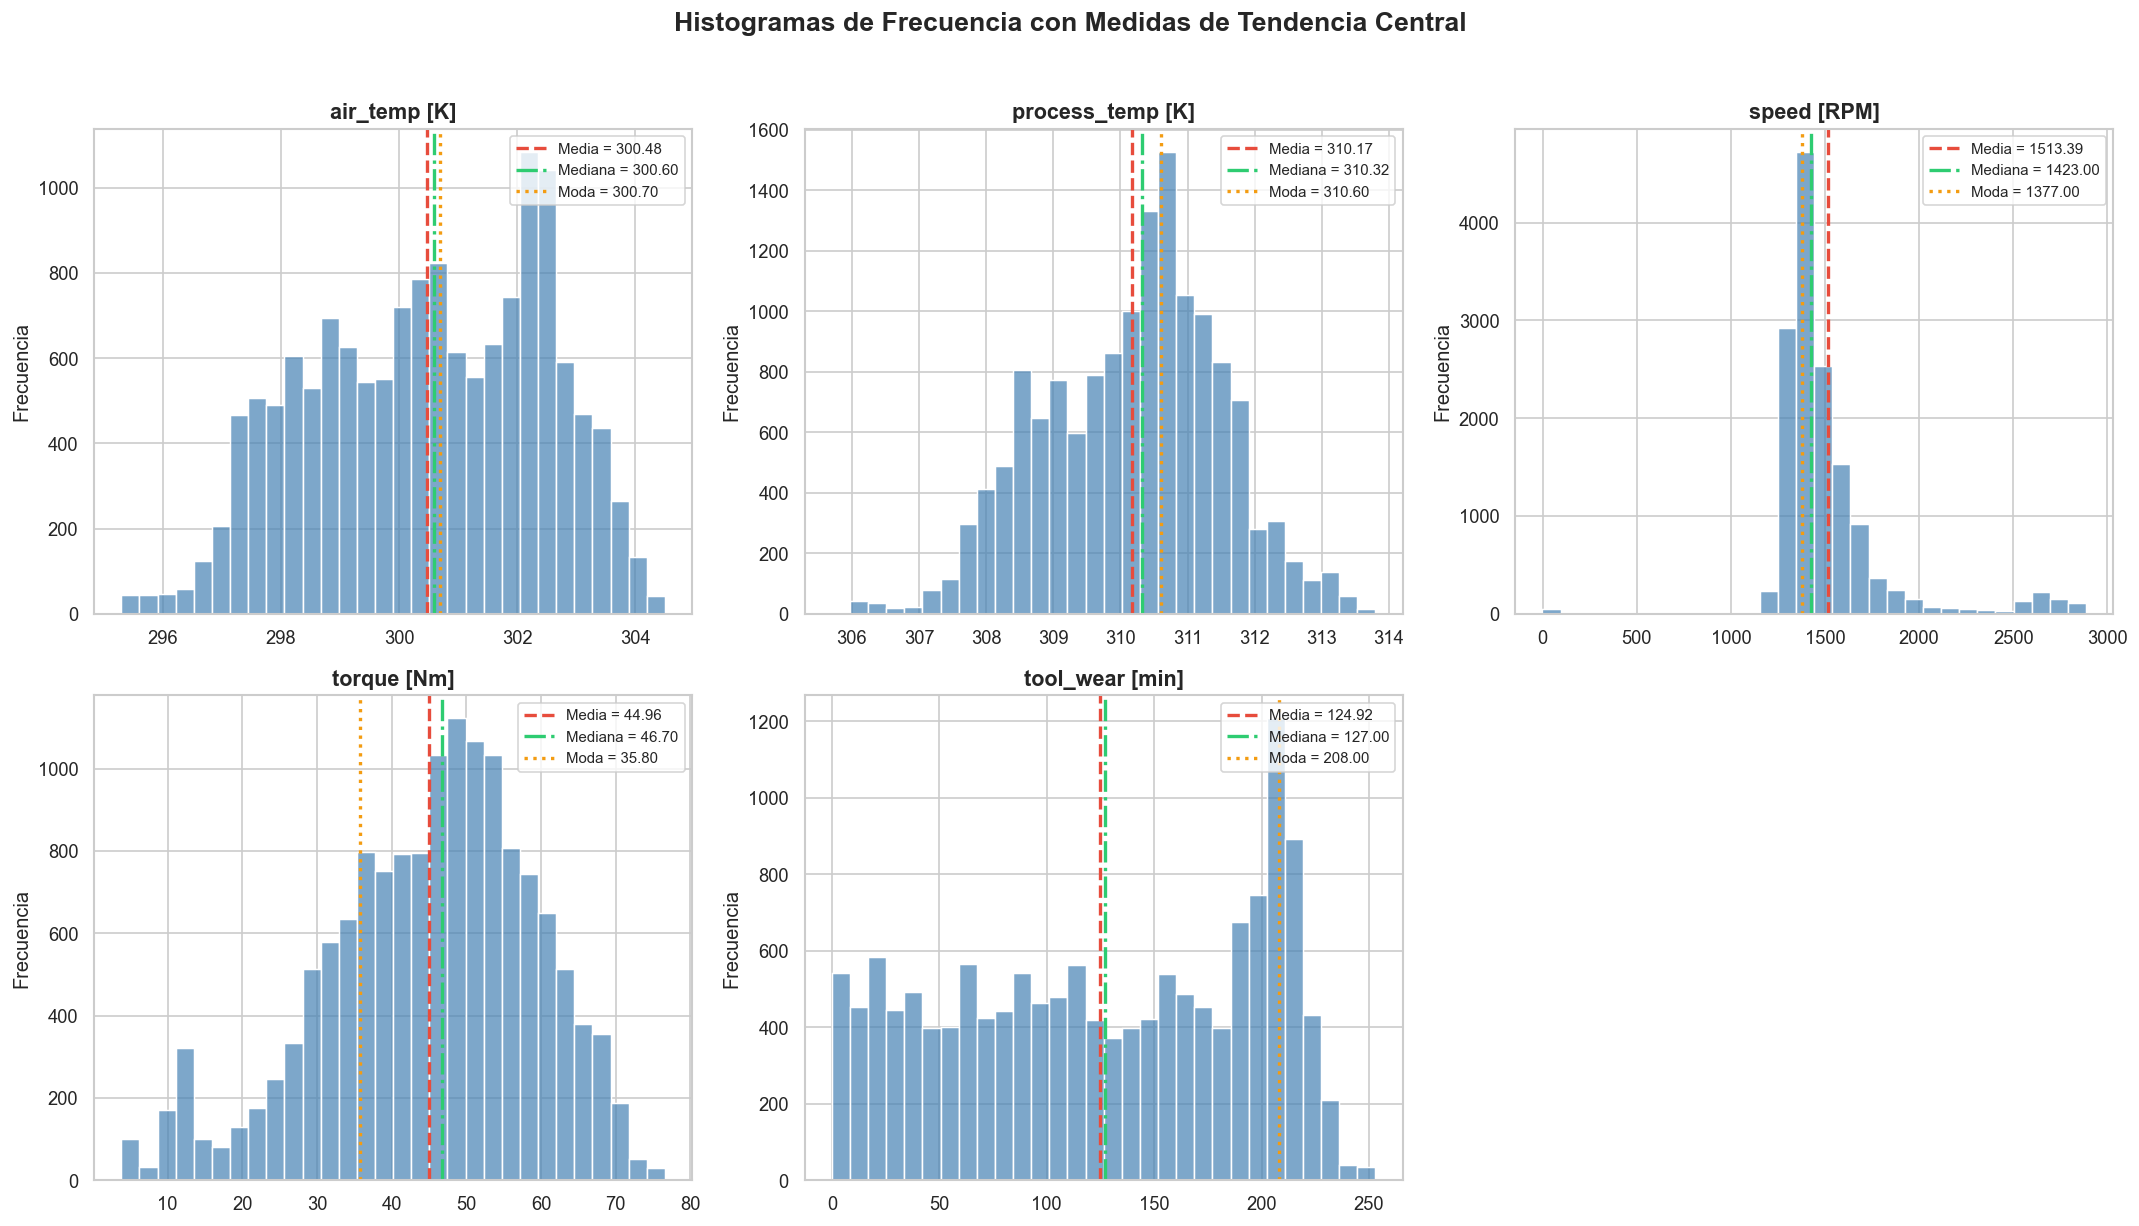

In [121]:
# Seleccionar únicamente las columnas numéricas relevantes (excluimos idx y parent_device_id)
columnas_numericas = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]

    # Histograma (frecuencia absoluta)
    sns.histplot(x = df[col], bins=30, kde=False, color='steelblue', edgecolor='white',
                 alpha=0.7, ax=ax, stat='count')

    # Cálculo de medidas de tendencia central
    media   = df[col].mean()
    mediana = df[col].median()
    moda    = df[col].mode()[0]

    # Líneas verticales para cada medida
    ax.axvline(media,   color='#e74c3c', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
    ax.axvline(mediana, color='#2ecc71', linestyle='-.',  linewidth=2, label=f'Mediana = {mediana:.2f}')
    ax.axvline(moda,    color='#f39c12', linestyle=':',   linewidth=2, label=f'Moda = {moda:.2f}')

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9, loc='upper right')

# Ocultar el subplot vacío (tenemos 5 gráficos en una grilla de 2x3)
axes[-1].set_visible(False)

fig.suptitle('Histogramas de Frecuencia con Medidas de Tendencia Central', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- Las columnas air_temp [K], process_temp [K] y torque [Nm] presentan distribuciones que parecen ser aproximadamente normales.
- Por otro lado, las columnas speed [RPM] y tool_wear [min] parecieran seguir alguna otra distribución. Incluso pareciendo una distribución exponencial en Speed [RPM] si quitamos el outlier de la izquierda

### Medidas de Dispersión

### Proporciones de las Columnas Categóricas

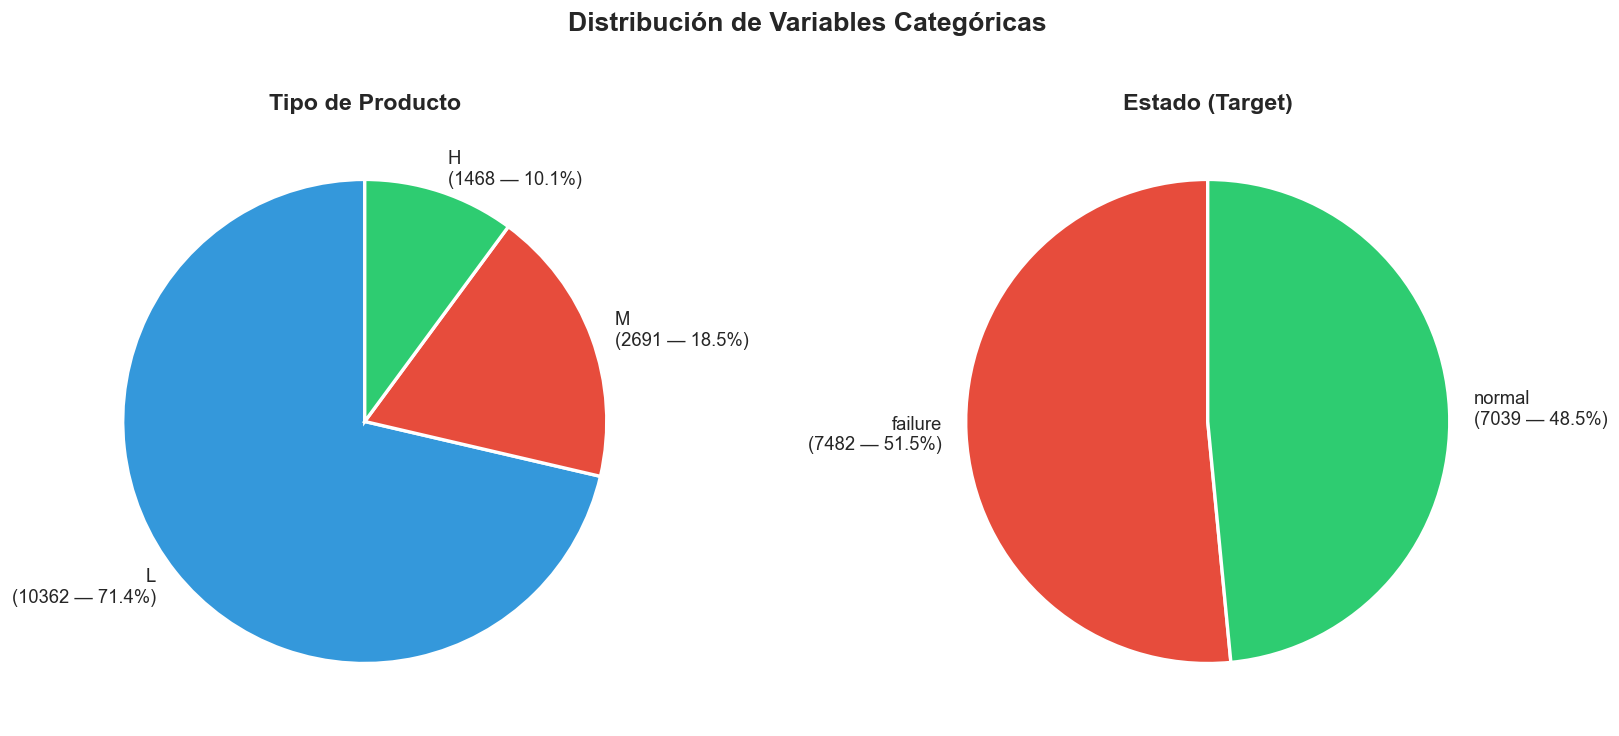

In [122]:
columnas_categoricas = ['product_type', 'target']
titulos = ['Tipo de Producto', 'Estado (Target)']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Paletas de colores
paletas = [
    ['#3498db', '#e74c3c', '#2ecc71'],   # product_type: L, M, H
    ['#e74c3c', '#2ecc71']               # target: failure, normal
]

for i, col in enumerate(columnas_categoricas):
    ax = axes[i]
    conteos = df[col].value_counts()
    proporciones = conteos / conteos.sum() * 100

    # Etiquetas con conteo y porcentaje
    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos.index, conteos.values, proporciones.values)]

    wedges, texts = ax.pie(
        conteos.values,
        labels=etiquetas,
        colors=paletas[i],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    # Ajustar tamaño de fuente de etiquetas
    for t in texts:
        t.set_fontsize(11)

    ax.set_title(titulos[i], fontsize=14, fontweight='bold')

fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- Con la proporción de la columna target (Estado), se puede observar que el dataset está ligeramente desbalanceado. Sabiendo esto, se podrían aplicar técnicas de balanceo de clases en etapas posteriores del análisis para mejorar el rendimiento de los modelos predictivos. Sin embargo, también hay que considerar la posibilidad de no balancear en absoluto, dado que:
    - La diferencia de proporción es mínima.
    - Y en teoría, cuando hay desbalanceo de clases, los modelos tienen a dar mejores resultados en la clase mayoritaria, lo que podría ser beneficioso en este caso, ya que el objetivo es predecir si hay una falla en las máquinas, y bajo este escenario puede ser preferible tener un falso positivo de falla antes que clasificar una falla como normal.

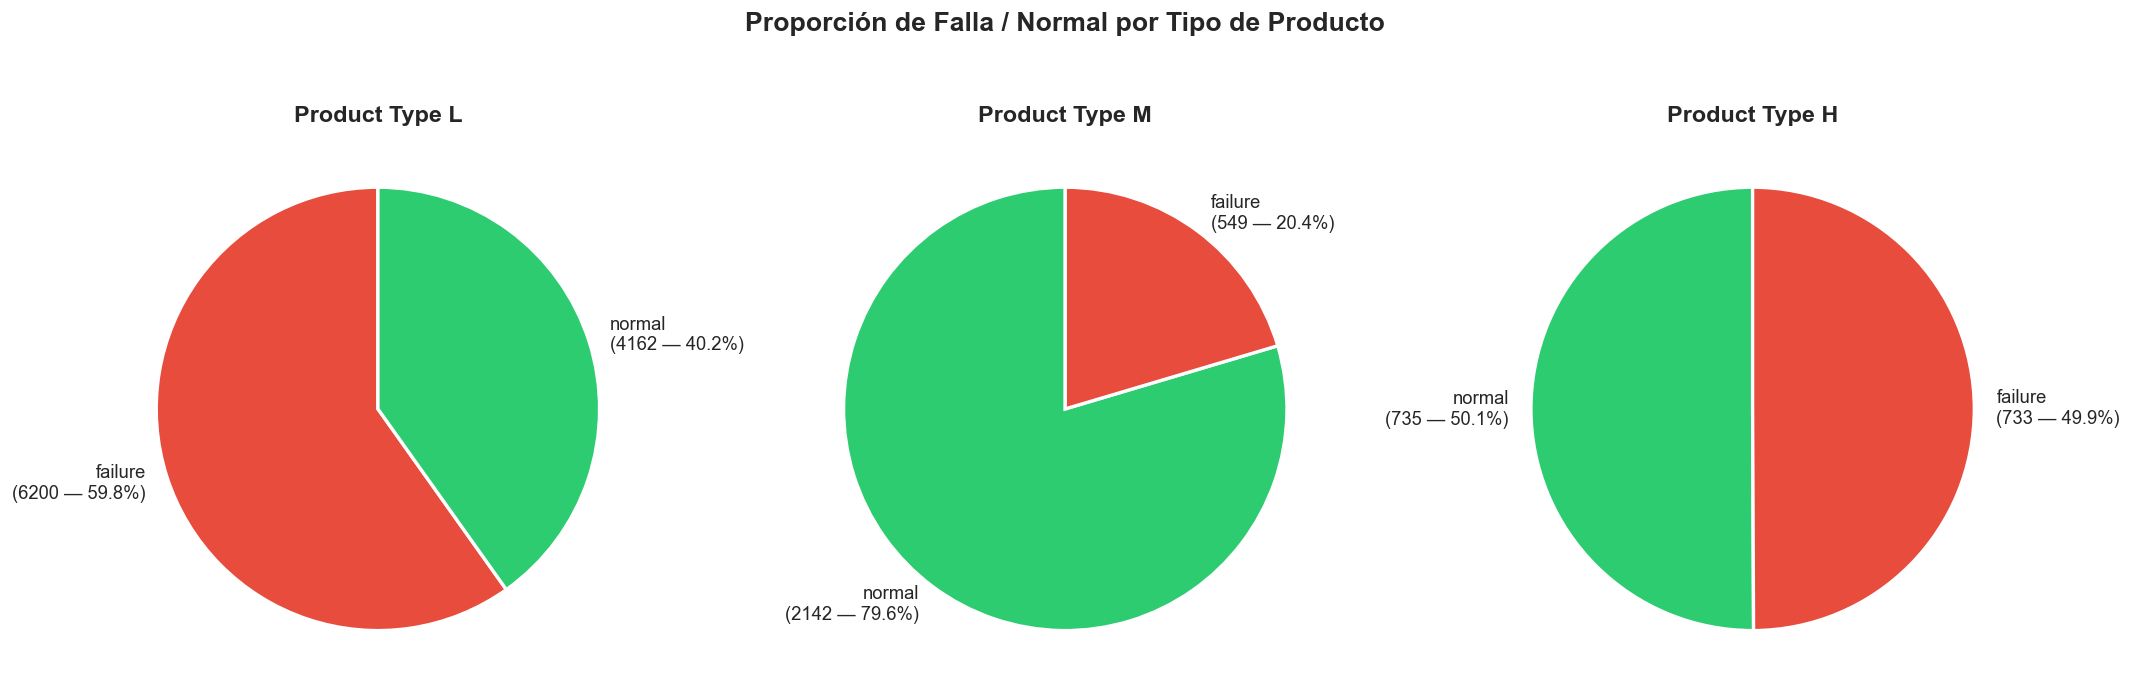

In [123]:
tipos_producto = ['L', 'M', 'H']
color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, prod in enumerate(tipos_producto):
    ax = axes[i]
    conteos = df.loc[df['product_type'] == prod, 'target'].value_counts()
    proporciones = conteos / conteos.sum() * 100

    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos.index, conteos.values, proporciones.values)]
    
    # Asignar los colores haciendo un mapeo estático con el índice (categoría) para asegurar consistencia
    colores_pie = [color_map[idx] for idx in conteos.index]

    wedges, texts = ax.pie(
        conteos.values,
        labels=etiquetas,
        colors=colores_pie,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    for t in texts:
        t.set_fontsize(11)

    ax.set_title(f'Product Type {prod}', fontsize=14, fontweight='bold')

fig.suptitle('Proporción de Falla / Normal por Tipo de Producto', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- La proporciones para product_type "L" presenta la proporción más alta de fallas, cercana al 60%, lo cual podría indicar que este tipo de producto es particularmente susceptible a fallas (quiza este tipo de producto es más vulnerable al proceso productivo). 
- El tipo de producto "H" muestra proporciones inusualmente equilibradas entre "normal" y "failure" (cercanas al 50/50), lo cual resulta llamativo dado que, en condiciones normales de operación, las fallas suelen representar una proporción significativamente menor. 
- Por otro lado, la proporción para product_type "M" indica que solo el 20% de los productos del tipo M tienen una falla, lo que podría sugerir que el tipo de producto M es menos propenso a fallas en comparación con los tipos L y H, tal vez por características específicas de ese tipo de producto o por condiciones de operación particulares. Esto podría ser un punto de interés para investigar más a fondo en etapas posteriores del análisis.


*- raro que H tenga proporciones iguales y L tenga un 60% de fallas, siempre las roturas son mucho menos*

**Esto refuerza la hipótesis de que el tipo de producto influye directamente en la probabilidad de falla, y constituye un punto de interés importante para investigar en etapas posteriores del análisis.**



### Diagramas de Caja (Box Plots)

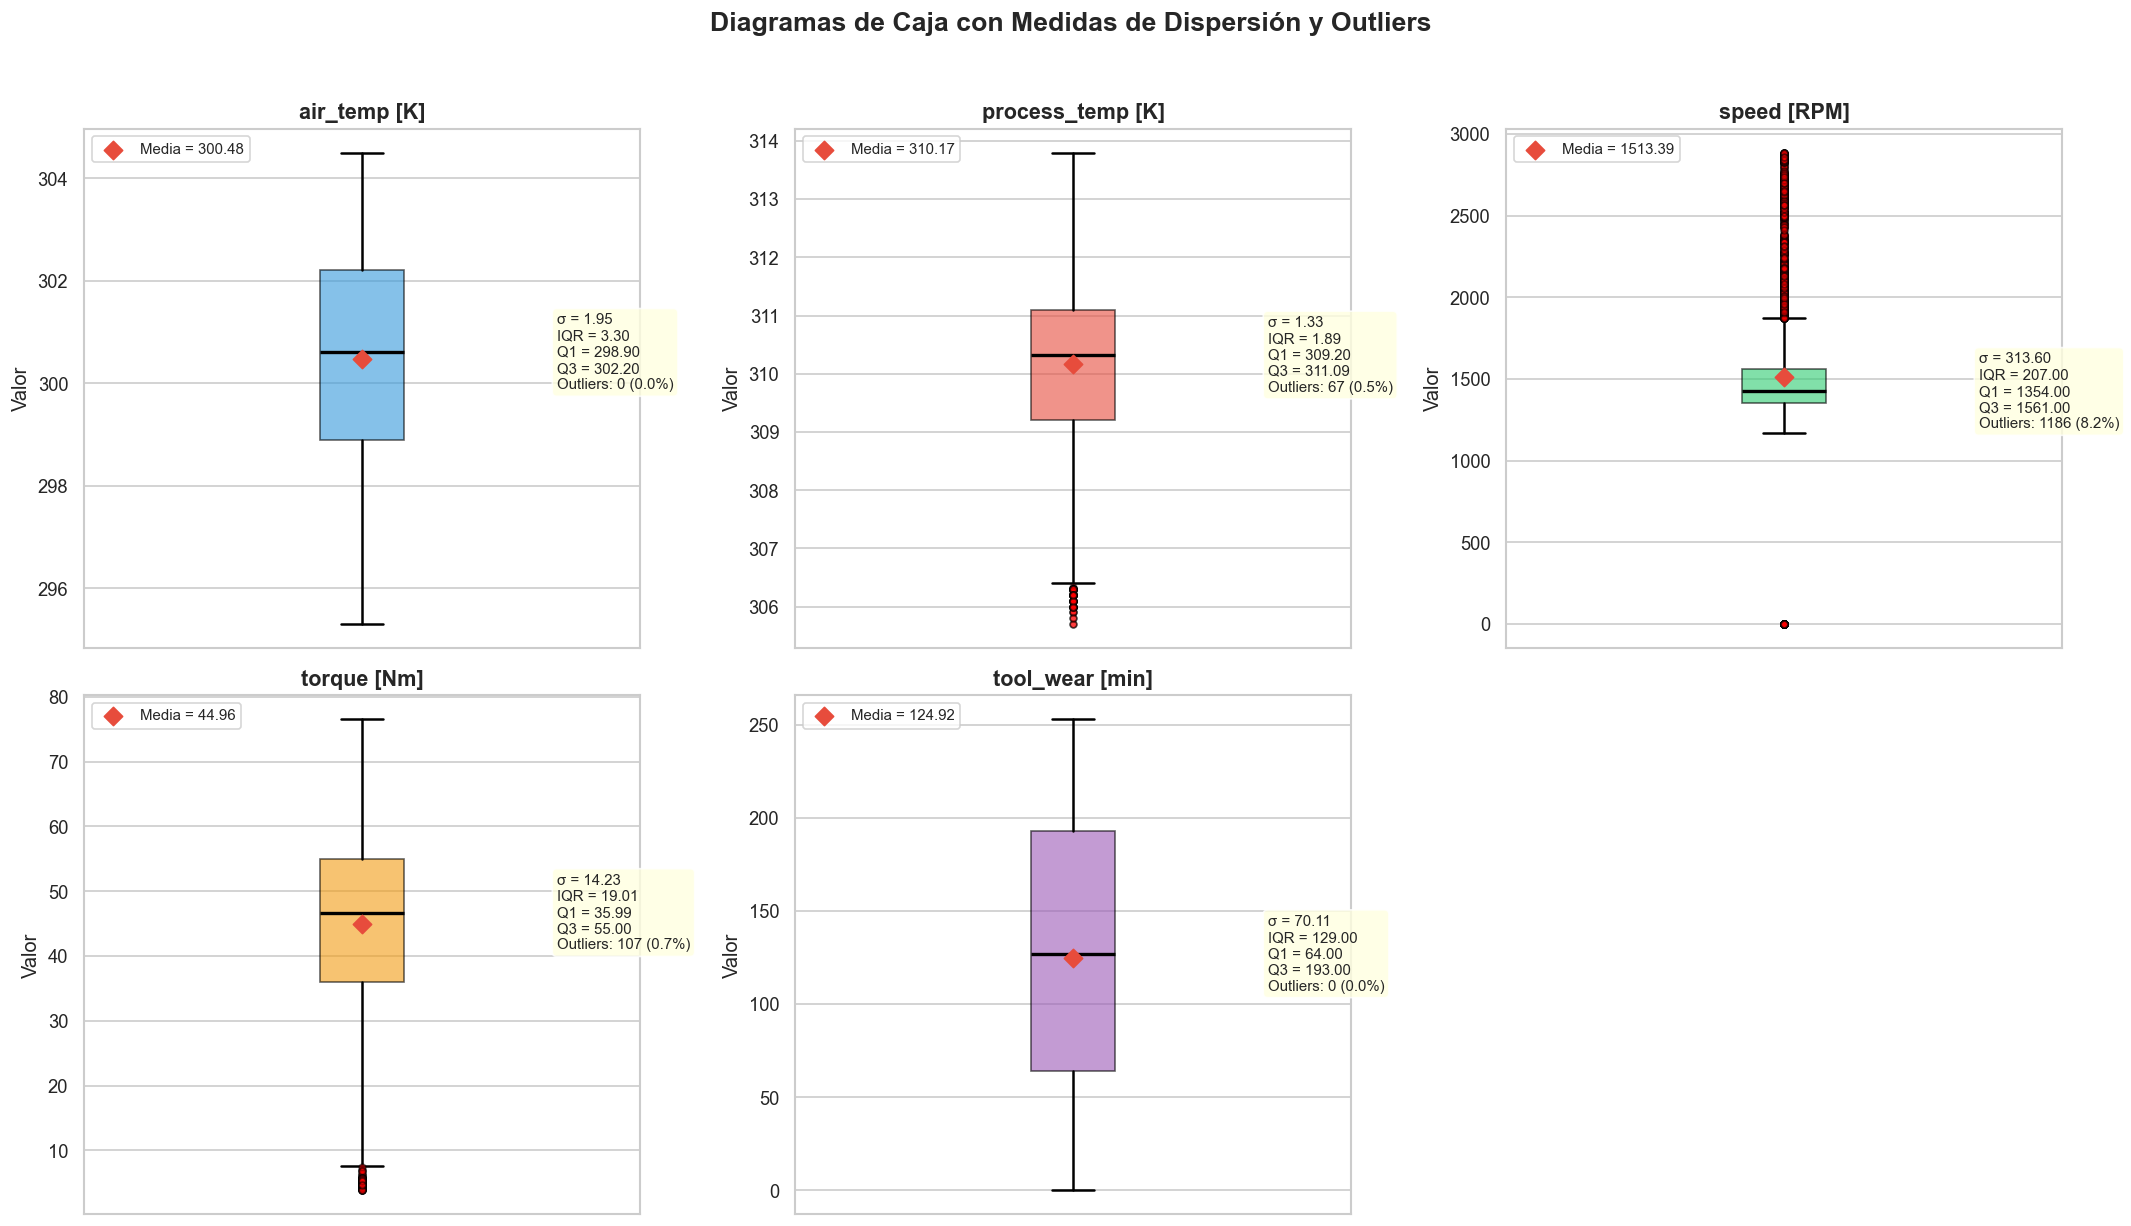

In [124]:
# --- Box Plots para cada variable numérica (con conteo de outliers) ---

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

colores_box = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, col in enumerate(columnas_numericas):
    df_sin_nulos = df[col].dropna()
    
    ax = axes[i]

    bp = ax.boxplot(df_sin_nulos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colores_box[i], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))

    # Estadísticas
    media   = df_sin_nulos.mean()
    std     = df_sin_nulos.std()
    mediana = df_sin_nulos.median()
    q1      = df_sin_nulos.quantile(0.25)
    q3      = df_sin_nulos.quantile(0.75)
    iqr     = q3 - q1

    # Contar outliers (método IQR: valores fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR])
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    n_out   = ((df_sin_nulos < lim_inf) | (df_sin_nulos > lim_sup)).sum()
    pct_out = n_out / len(df_sin_nulos) * 100

    # Marcar la media con un diamante
    ax.scatter([1], [media], marker='D', color='#e74c3c', s=60, zorder=5, label=f'Media = {media:.2f}')

    # Texto con estadísticas de dispersión + outliers
    stats_text = (f'σ = {std:.2f}\n'
                  f'IQR = {iqr:.2f}\n'
                  f'Q1 = {q1:.2f}\n'
                  f'Q3 = {q3:.2f}\n'
                  f'Outliers: {n_out} ({pct_out:.1f}%)')
    ax.text(1.35, mediana, stats_text, fontsize=9, va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xticks([])
    ax.legend(fontsize=9, loc='upper left')

# Ocultar el subplot vacío
axes[-1].set_visible(False)

fig.suptitle('Diagramas de Caja con Medidas de Dispersión y Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

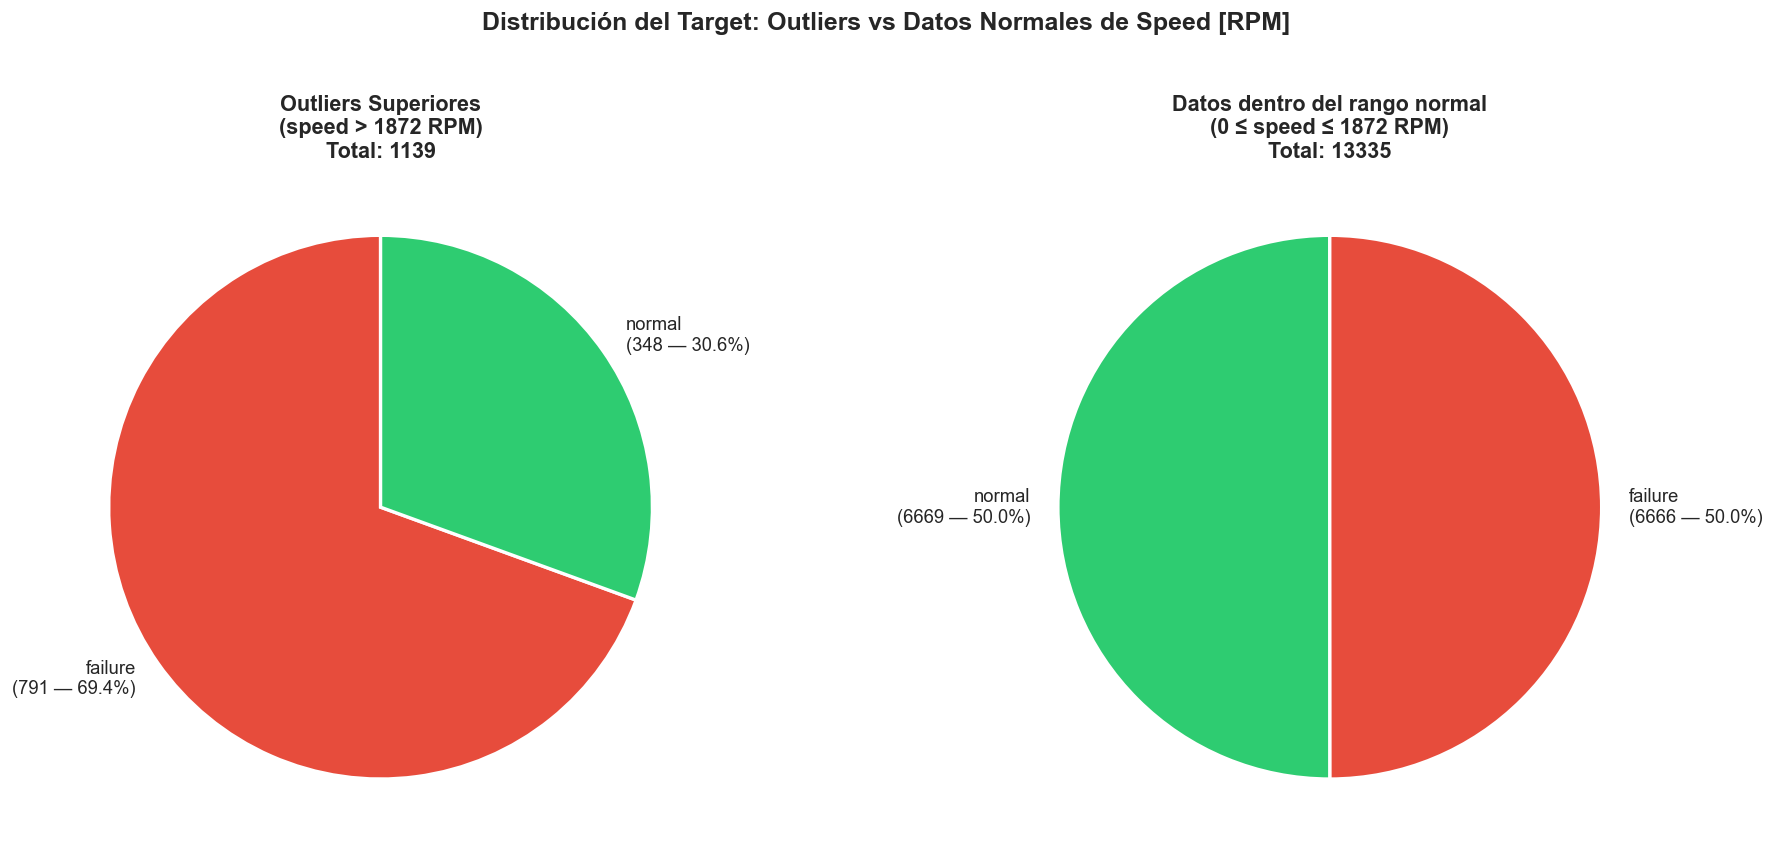

In [125]:
# Detección de outliers superiores en speed [RPM] usando el método IQR
Q1 = df['speed [RPM]'].quantile(0.25)
Q3 = df['speed [RPM]'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

# Excluir los valores -1 (tratados como faltantes) y separar outliers superiores del resto
datos_validos = df[df['speed [RPM]'] >= 0]  # Excluir valores -1

outliers_speed = datos_validos[datos_validos['speed [RPM]'] > limite_superior]
no_outliers_speed = datos_validos[datos_validos['speed [RPM]'] <= limite_superior]

color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

# --- Gráfico 1: Outliers superiores ---
conteos_out = outliers_speed['target'].value_counts()
proporciones_out = conteos_out / conteos_out.sum() * 100

etiquetas_out = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos_out.index, conteos_out.values, proporciones_out.values)]
colores_out = [color_map[idx] for idx in conteos_out.index]

wedges1, texts1 = axes[0].pie(
    conteos_out.values,
    labels=etiquetas_out,
    colors=colores_out,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in texts1:
    t.set_fontsize(11)

axes[0].set_title(
    f'Outliers Superiores\n(speed > {limite_superior:.0f} RPM)\n'
    f'Total: {len(outliers_speed)}',
    fontsize=13, fontweight='bold'
)

# --- Gráfico 2: Datos dentro del rango normal ---
conteos_no = no_outliers_speed['target'].value_counts()
proporciones_no = conteos_no / conteos_no.sum() * 100

etiquetas_no = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                in zip(conteos_no.index, conteos_no.values, proporciones_no.values)]
colores_no = [color_map[idx] for idx in conteos_no.index]

wedges2, texts2 = axes[1].pie(
    conteos_no.values,
    labels=etiquetas_no,
    colors=colores_no,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in texts2:
    t.set_fontsize(11)

axes[1].set_title(
    f'Datos dentro del rango normal\n(0 ≤ speed ≤ {limite_superior:.0f} RPM)\n'
    f'Total: {len(no_outliers_speed)}',
    fontsize=13, fontweight='bold'
)

fig.suptitle(
    'Distribución del Target: Outliers vs Datos Normales de Speed [RPM]',
    fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()


**Observaciones:**

Se excluyen del análisis los valores atípicos inferiores de speed [RPM] dado que corresponden a registros con valor -1, los cuales representan datos faltantes que serán imputados en etapas posteriores (10 registros en total).

De los 1139 registros identificados como outliers superiores (velocidades por encima del límite del diagrama de caja), el **69.4% (791) presentan fallas**, frente al aproximadamente 50% que se observa en los 13335 registros dentro del rango normal. Esta diferencia de casi 20 puntos porcentuales es **considerable y estadísticamente relevante dado el tamaño de la muestra**.

Esto sugiere que **las velocidades atípicamente altas tienen una incidencia directa y significativa en la ocurrencia de fallas**, lo cual es consistente con lo esperado en un contexto de mantenimiento predictivo industrial, donde velocidades excesivas generan mayor desgaste, vibración y estrés mecánico.

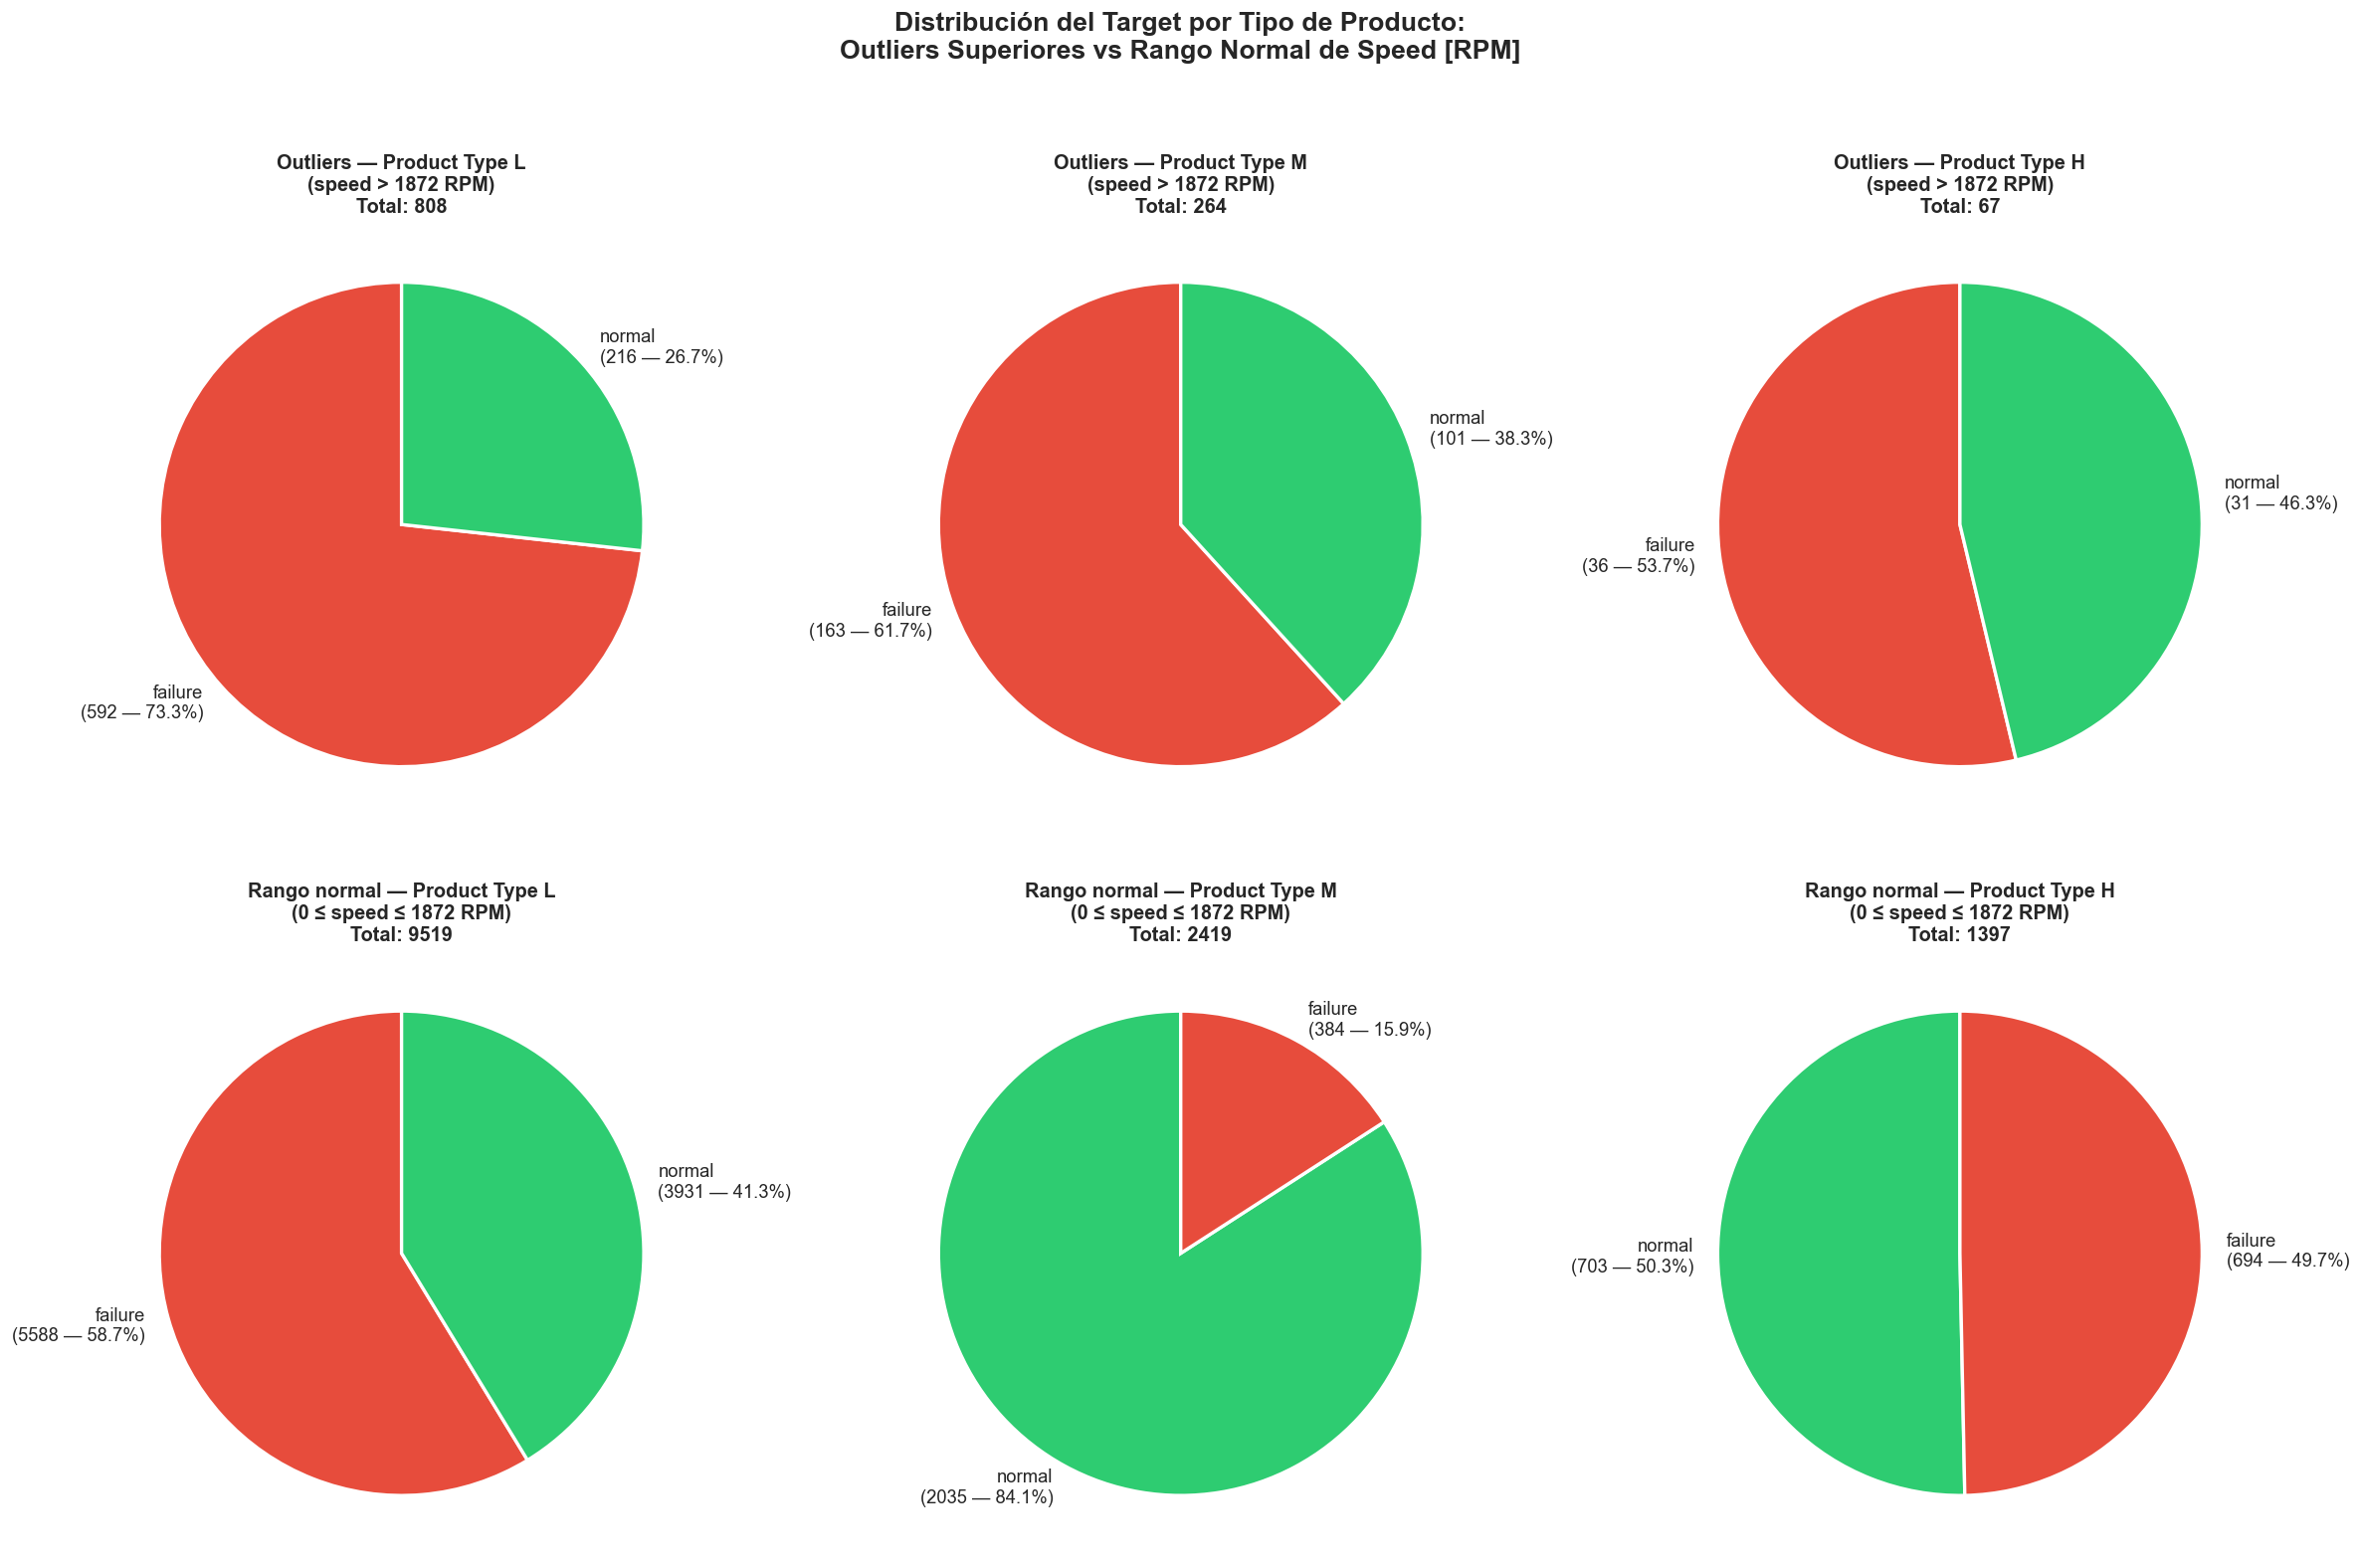

In [126]:
# Detección de outliers superiores en speed [RPM] usando el método IQR
Q1 = df['speed [RPM]'].quantile(0.25)
Q3 = df['speed [RPM]'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Excluir valores -1 (faltantes) y separar outliers del resto
datos_validos = df[df['speed [RPM]'] >= 0]
outliers_speed = datos_validos[datos_validos['speed [RPM]'] > limite_superior]
no_outliers_speed = datos_validos[datos_validos['speed [RPM]'] <= limite_superior]

tipos_producto = ['L', 'M', 'H']
color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 13))

for i, pt in enumerate(tipos_producto):
    # --- Fila 1: Outliers superiores por tipo de producto ---
    subset_out = outliers_speed[outliers_speed['product_type'] == pt]

    if len(subset_out) > 0:
        conteos_out = subset_out['target'].value_counts()
        proporciones_out = conteos_out / conteos_out.sum() * 100

        etiquetas_out = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                         in zip(conteos_out.index, conteos_out.values, proporciones_out.values)]
        colores_out = [color_map[idx] for idx in conteos_out.index]

        wedges, texts = axes[0][i].pie(
            conteos_out.values,
            labels=etiquetas_out,
            colors=colores_out,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for t in texts:
            t.set_fontsize(11)
    else:
        axes[0][i].text(0.5, 0.5, 'Sin outliers', ha='center', va='center', fontsize=12)

    axes[0][i].set_title(
        f'Outliers — Product Type {pt}\n(speed > {limite_superior:.0f} RPM)\nTotal: {len(subset_out)}',
        fontsize=12, fontweight='bold'
    )

    # --- Fila 2: Datos normales por tipo de producto ---
    subset_no = no_outliers_speed[no_outliers_speed['product_type'] == pt]

    if len(subset_no) > 0:
        conteos_no = subset_no['target'].value_counts()
        proporciones_no = conteos_no / conteos_no.sum() * 100

        etiquetas_no = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                        in zip(conteos_no.index, conteos_no.values, proporciones_no.values)]
        colores_no = [color_map[idx] for idx in conteos_no.index]

        wedges2, texts2 = axes[1][i].pie(
            conteos_no.values,
            labels=etiquetas_no,
            colors=colores_no,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for t in texts2:
            t.set_fontsize(11)
    else:
        axes[1][i].text(0.5, 0.5, 'Sin datos', ha='center', va='center', fontsize=12)

    axes[1][i].set_title(
        f'Rango normal — Product Type {pt}\n(0 ≤ speed ≤ {limite_superior:.0f} RPM)\nTotal: {len(subset_no)}',
        fontsize=12, fontweight='bold'
    )

fig.suptitle(
    'Distribución del Target por Tipo de Producto:\nOutliers Superiores vs Rango Normal de Speed [RPM]',
    fontsize=16, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()


### **Observaciones**:
Al desagregar el análisis por tipo de producto, se revelan patrones que refuerzan la hipótesis de que las categorías L, M y H representan niveles de calidad (Low, Medium, High) de los productos utilizados:

**Producto tipo L (Low / Baja calidad):**
- En el rango normal de velocidades ya presenta una tasa de fallas muy alta (58.7%), la más elevada de los tres tipos.
- Al operar a velocidades atípicamente altas, la tasa de fallas asciende al 73.3% (+14.6 puntos porcentuales).
- Además, concentra la mayor cantidad de outliers (808 de 1139, es decir, el 70.9%), lo cual sugiere que los productos de baja calidad no solo fallan más, sino que también tienden a operar fuera de los rangos normales con mayor frecuencia.
- Este comportamiento es consistente con un producto de baja calidad: inherentemente más propenso a fallas en cualquier condición, y con mayor degradación a velocidades extremas.

**Producto tipo M (Medium / Calidad media):**
- En condiciones normales de velocidad presenta la tasa de fallas más baja de los tres tipos, con apenas un 15.9%. Esto indica un producto confiable cuando opera dentro de sus parámetros de diseño.
- Sin embargo, al operar a velocidades atípicas, la tasa de fallas se dispara al 61.7%, un incremento de casi 46 puntos porcentuales, el salto más drástico de los tres tipos.
- Esto es consistente con un producto de calidad intermedia: bien diseñado para condiciones normales de operación, pero que se degrada significativamente cuando se lo somete a condiciones extremas para las que no fue dimensionado.

**Producto tipo H (High / Alta calidad / Dureza alta):**
- En el rango normal de velocidades presenta una tasa de fallas de ~50%, similar a la observada en los análisis previos.
- Al operar a velocidades atípicas, la tasa apenas sube al 53.7% (+4 puntos porcentuales), la variación más pequeña de los tres tipos.
- Si bien la cantidad de outliers es reducida (67), este patrón sugiere que los productos de alta calidad son los más resistentes a la degradación por velocidades extremas, ya que su tasa de fallas prácticamente no varía al operar fuera del rango normal.
- No obstante, su tasa de fallas base de ~50% (ya observada y señalada como anómala en análisis previos) podría deberse a otros factores de falla no relacionados con la velocidad, lo cual requiere investigación adicional.

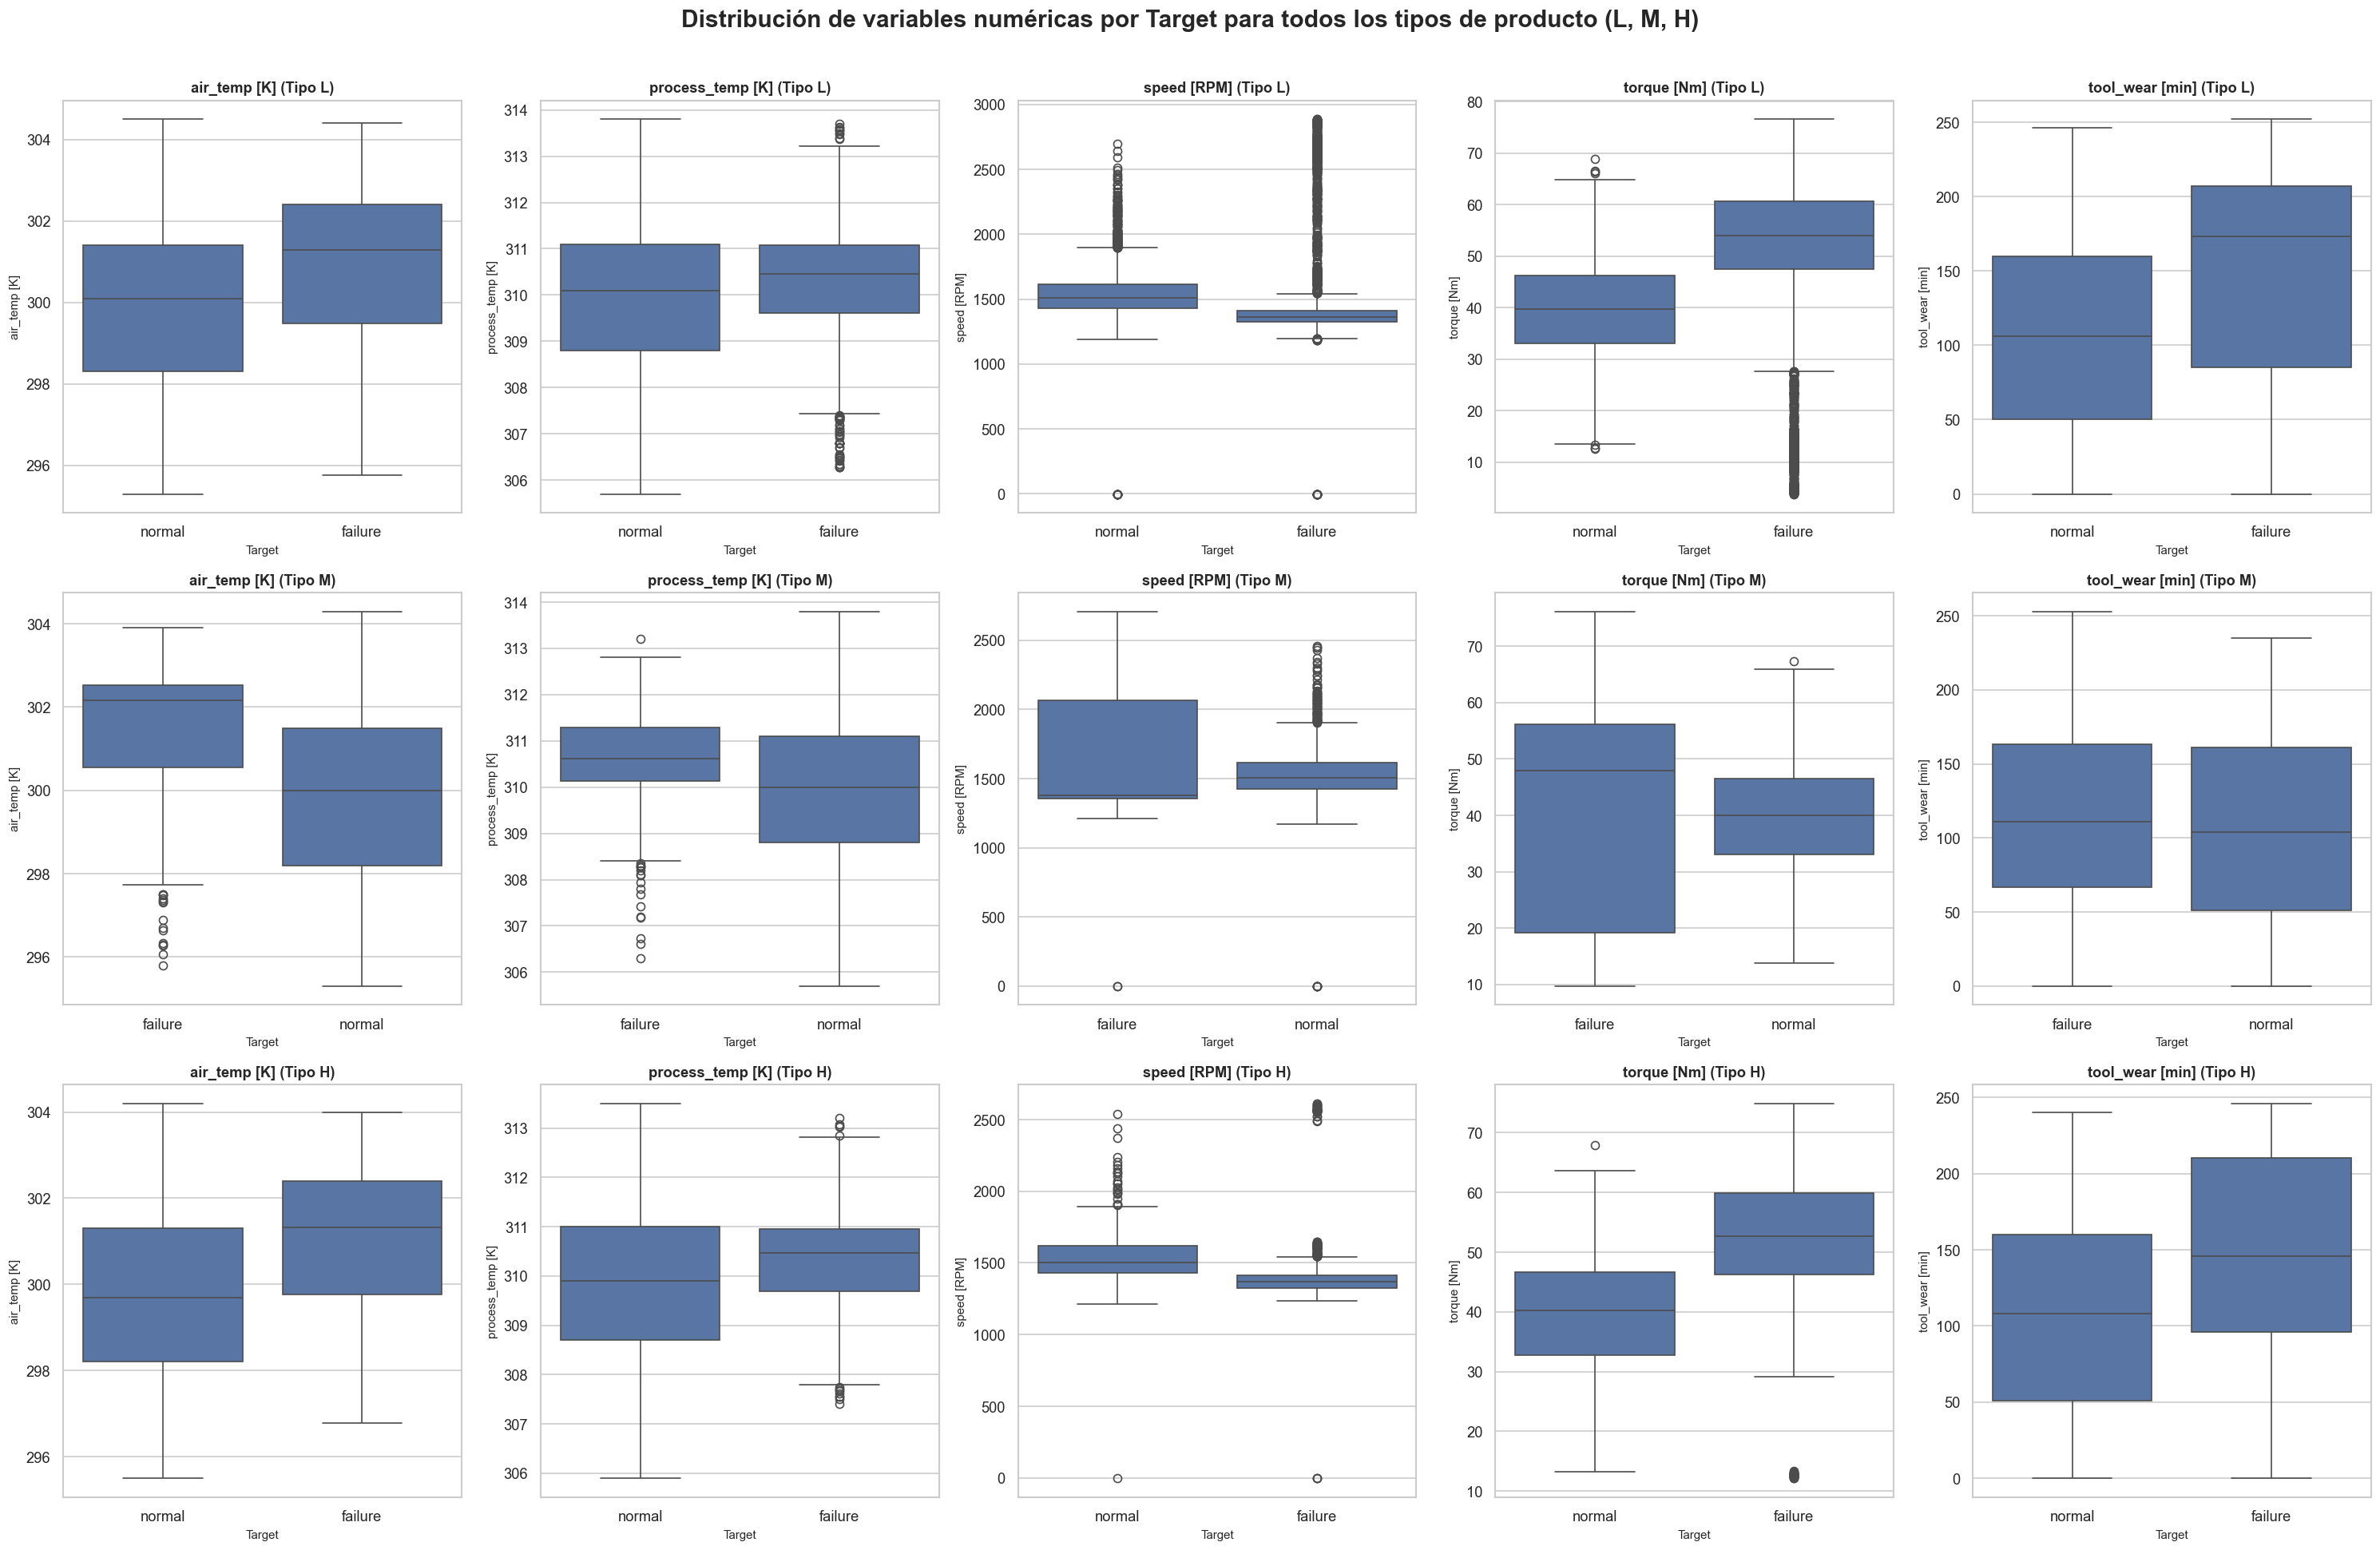

In [127]:
variables_numericas = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
product_types = ['L', 'M', 'H']

# Creamos una cuadrícula de 3 filas (una por producto) y 5 columnas (una por variable)
fig, axes = plt.subplots(nrows=len(product_types), ncols=len(variables_numericas), figsize=(25, 16))

for r, prod_type in enumerate(product_types):
    # Filtramos el dataset para el tipo de producto actual
    df_filtered = df[df['product_type'] == prod_type]
    
    for c, var in enumerate(variables_numericas):
        ax = axes[r, c]
        # Dibujamos el boxplot
        sns.boxplot(data=df_filtered, x='target', y=var, ax=ax)
        
        # Título de cada gráfico individual indicando la variable y el tipo de producto
        ax.set_title(f'{var} (Tipo {prod_type})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Target', fontsize=9)
        ax.set_ylabel(var, fontsize=9)

# Título general superior de la figura completa
fig.suptitle('Distribución de variables numéricas por Target para todos los tipos de producto (L, M, H)', 
             fontsize=18, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()


### Análisis Comparativo de Distribuciones Numéricas por Tipo de Producto (L, M, H)

Para comprender en profundidad el comportamiento operativo y los modos de falla de cada tipo de producto, se analizaron los gráficos de caja (*boxplots*) de las variables físicas numéricas segmentados por la variable objetivo (`target`). 

#### Comportamiento y Hallazgos por Variable Física

##### A. Perfiles Térmicos (`air_temp [K]` y `process_temp [K]`)
* **Observación:** En los tres tipos de producto (**L, M y H**), las instancias clasificadas como `failure` se concentran en rangos de temperatura (tanto ambiental como del proceso) sensiblemente superiores en comparación con el estado `normal`.
* **Conclusión:** Esto aporta evidencia robusta sobre la presencia del modo de falla por **Disipación Térmica (HDF - *Heat Dissipation Failure*)** como un fenómeno transversal, donde el sobrecalentamiento operativo actúa como detonante del fallo independientemente de la robustez del material.

##### B. Dinámica de Operación (`speed [RPM]` y `torque [Nm]`)
* **Tipos L y H:** Presentan un comportamiento operativo normal muy acotado (velocidad en torno a 1500 RPM y torque en 40 Nm). En situaciones de falla, muestran una clara polarización:
  * Fallas por sobrecarga en baja velocidad y alto torque (fatiga mecánica).
  * Caídas abruptas de torque a valores inferiores a ~15 Nm acompañadas de altas revoluciones, lo cual se alinea con roturas mecánicas catastróficas instantáneas (pérdida repentina de carga).
* **Tipo M:** Las fallas exhiben un comportamiento mucho más disperso. El rango de velocidad de falla abarca desde 1300 hasta 2000 RPM, y el torque de falla se extiende ampliamente entre 20 y 55 Nm, sugiriendo que la calidad M experimenta fallas en regímenes intermedios no necesariamente extremos.

##### C. Desgaste de Herramienta (`tool_wear [min]`)
* **Tipos L y H:** Muestran una progresión ordinal lógica esperada. En estado `normal`, la mediana de desgaste se sitúa cercana a los 100 minutos, mientras que en estado de `failure`, la mediana asciende considerablemente (superando los 150 min para L y los 170 min para H). Esto convalida el modo de falla por **Desgaste de Herramienta (TWF - *Tool Wear Failure*)** por envejecimiento natural de la broca.
* **Tipo M (Anomalía Detectada):** En esta calidad, la distribución del desgaste de la herramienta es **prácticamente idéntica** entre los estados `normal` y `failure` (ambas medianas convergen en torno a los 110 minutos).
* **Conclusión:** Este hallazgo revela que **el Tipo M rara vez experimenta fallas por desgaste físico acumulado**. Las herramientas de tipo M tienden a fallar de forma prematura debido a factores operacionales dinámicos (picos de torque o fluctuaciones de velocidad) antes de alcanzar un desgaste temporal avanzado.


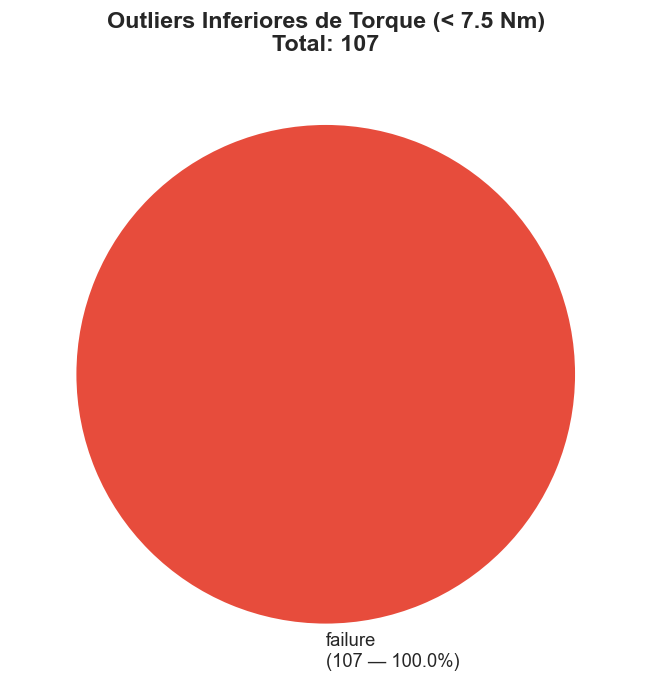

In [128]:
# Detección de outliers inferiores en torque [Nm]
Q1_torque = df['torque [Nm]'].quantile(0.25)
Q3_torque = df['torque [Nm]'].quantile(0.75)
IQR_torque = Q3_torque - Q1_torque
limite_inferior_torque = Q1_torque - 1.5 * IQR_torque

outliers_bajos_torque = df[df['torque [Nm]'] < limite_inferior_torque]

if len(outliers_bajos_torque) > 0:
    conteos_bajos = outliers_bajos_torque['target'].value_counts()
    proporciones_bajos = conteos_bajos / conteos_bajos.sum() * 100

    color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}
    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos_bajos.index, conteos_bajos.values, proporciones_bajos.values)]
    colores = [color_map.get(idx, '#95a5a6') for idx in conteos_bajos.index]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(conteos_bajos.values, labels=etiquetas, colors=colores, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'Outliers Inferiores de Torque (< {limite_inferior_torque:.1f} Nm)\nTotal: {len(outliers_bajos_torque)}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"No hay outliers inferiores (valores por debajo de {limite_inferior_torque:.1f} Nm)")

      


Se buscará el valor máximo de torque desde el cual solo hay fallas.

In [129]:
# 1. Filtrar el DataFrame donde el torque es menor a umbral
umbral = 12.6
df_torque_bajo = df[df['torque [Nm]'] < umbral]

# Mostrar los primeros registros para inspeccionarlos
display(df_torque_bajo.head())

# 2. Verificar que efectivamente todos son 'failure'
print(f"\nDistribución del target en torque < {umbral}:")
print(df_torque_bajo['target'].value_counts())
print(df_torque_bajo['product_type'].value_counts())



,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
81,81,18566,L,301.76,311.05,2748,8.37,12,failure
124,124,18795,L,301.75,310.61,2669,11.83,122,failure
129,129,11162,L,303.48,312.67,2661,11.45,26,failure
146,146,18564,H,299.64,309.82,2584,12.52,89,failure
184,184,12538,M,299.59,309.56,2657,11.42,92,failure



Distribución del target en torque < 12.6:
target
failure    505
Name: count, dtype: int64
product_type
L    363
M    133
H      9
Name: count, dtype: int64


**Conclusión: El Torque Bajo como Predictor Perfecto y su relación con la Calidad**

El análisis profundo del límite inferior de `torque [Nm]` ha arrojado dos hallazgos concluyentes y de alto valor predictivo:

1. **Umbral de Falla Inminente:** 
Se ha identificado un umbral crítico de **12.6 Nm**. De los registros que caen por debajo de este valor de fuerza torsional, el 100% (505 casos) corresponden a fallas. Esto establece al torque bajo como un predictor perfecto ("regla de oro") para la clase minoritaria. Una pérdida repentina de resistencia en el mecanizado es sinónimo de rotura de herramienta o pérdida de sujeción.

2. **Validación de la Hipótesis de Calidad (L, M, H):**
Al observar qué productos sufren esta falla catastrófica de baja fuerza, los resultados son contundentes:
- **Product Type L:** 363 fallas (71.8%)
- **Product Type M:** 133 fallas (26.3%)
- **Product Type H:** 9 fallas (1.8%)

Esto corrobora la teoría de que L, M y H corresponden a calidades Baja, Media y Alta. Los productos de baja calidad (L) son altamente susceptibles a quebrarse o generar roturas repentinas que desploman el torque de la máquina. Por el contrario, los productos de alta calidad (H) son lo suficientemente robustos para casi nunca sufrir este tipo de colapso repentino (solo 9 casos). 

En resumen: el producto "L" se rompe por fragilidad (caída de torque a < 12.6 Nm), mientras que el producto "H", como se vio en análisis previos, solo cede cuando se lo somete a niveles de fuerza bruta extrema (torque elevado).


### Análisis de product_type bajo Condiciones Físicas Extremas

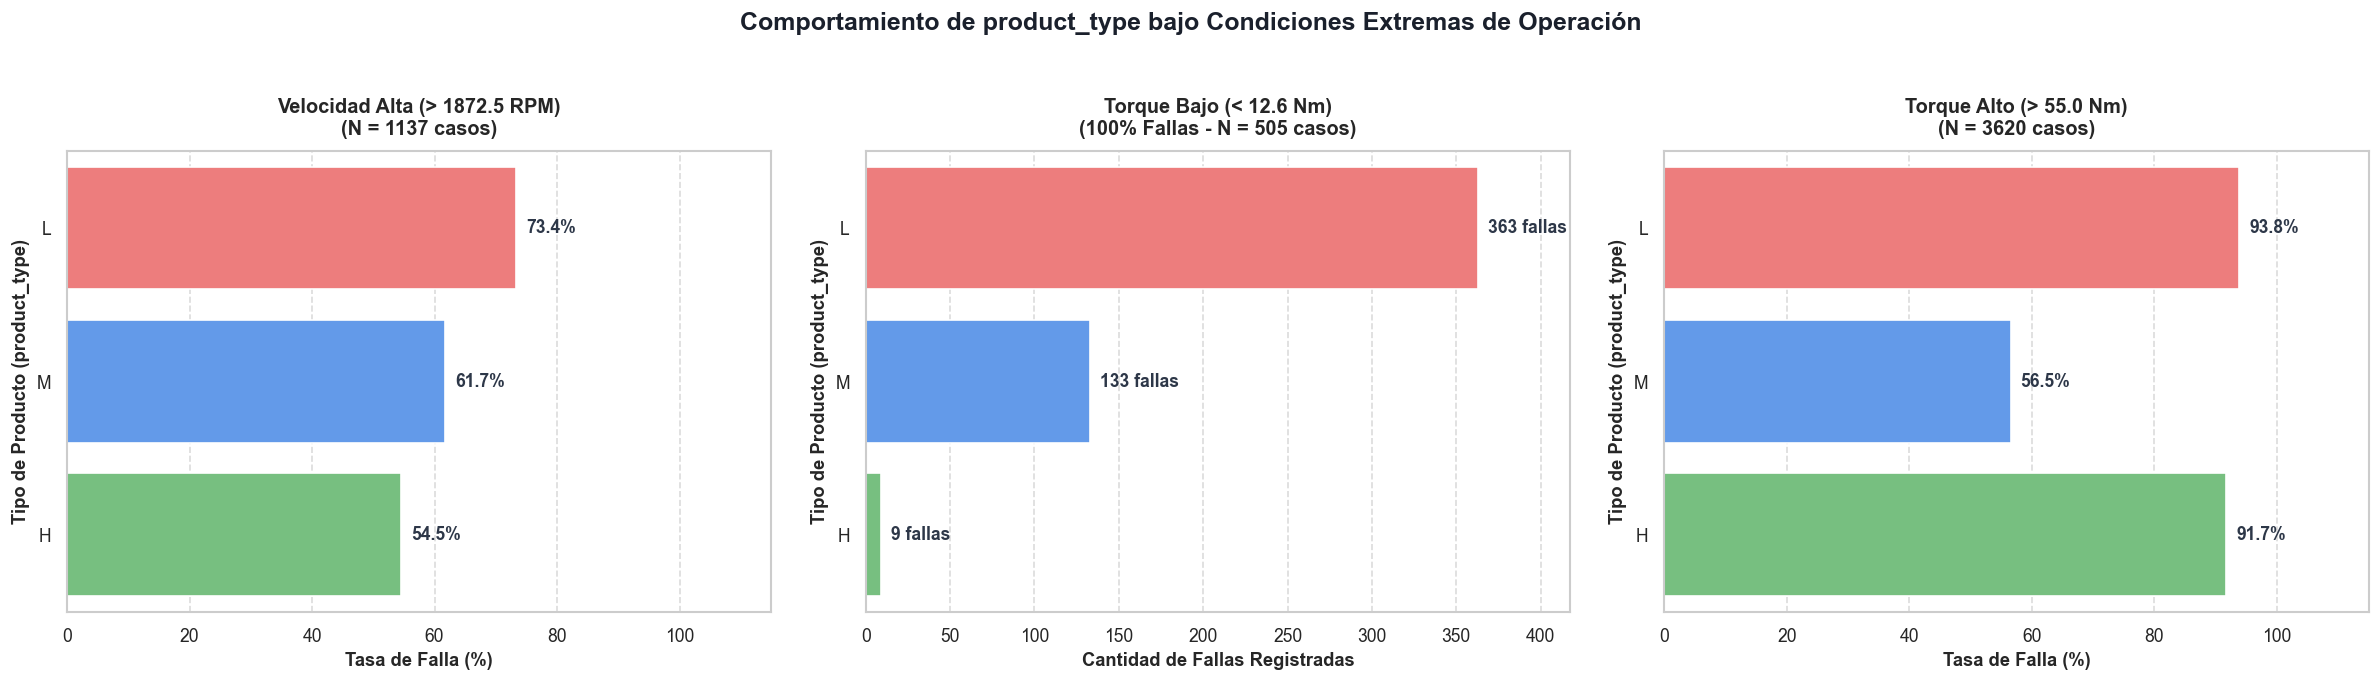

In [130]:
# 1. Definición dinámica de los límites y filtros
# Umbral dinámico de velocidad superior (outliers IQR)
q1_speed = df[df['speed [RPM]'] >= 0]['speed [RPM]'].quantile(0.25)
q3_speed = df[df['speed [RPM]'] >= 0]['speed [RPM]'].quantile(0.75)
iqr_speed = q3_speed - q1_speed
limite_sup_speed = q3_speed + 1.5 * iqr_speed  # 1872.5 RPM

# Umbrales de Torque
umbral_torque_bajo = 12.6  # Predictor perfecto inferior
umbral_torque_alto = 55.0  # Tercer cuartil (Q3) de torque

# Mapear el target de texto a binario ('normal' -> 0, 'failure' -> 1)
df_temp = df.copy()
df_temp['target_bin'] = df_temp['target'].map({'normal': 0, 'failure': 1})

# 2. Configurar la estética premium del gráfico y el layout (1 fila, 3 columnas)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5.5))

# Paleta HSL moderna y armoniosa para L, M, H
colores = {'L': '#FF6B6B', 'M': '#4D96FF', 'H': '#6BCB77'}

# --- GRÁFICO 1: Velocidad Alta ---
df_speed = df_temp[df_temp['speed [RPM]'] > limite_sup_speed]
tasas_speed = df_speed.groupby('product_type')['target_bin'].mean().reindex(['L', 'M', 'H']) * 100

sns.barplot(x=tasas_speed.values, y=tasas_speed.index, ax=axes[0], palette=colores, hue=tasas_speed.index, legend=False, orient='h')
axes[0].set_title(f'Velocidad Alta (> {limite_sup_speed:.1f} RPM)\n(N = {len(df_speed)} casos)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Tasa de Falla (%)', fontsize=11, fontweight='semibold')
axes[0].set_xlim(0, 115)

for bar in axes[0].patches:
    val = bar.get_width()
    if not pd.isna(val):
        axes[0].annotate(f'{val:.1f}%',
                         xy=(val, bar.get_y() + bar.get_height() / 2),
                         xytext=(6, 0), textcoords="offset points",
                         ha='left', va='center', fontsize=10.5, fontweight='bold', color='#2d3748')

# --- GRÁFICO 2: Torque Bajo (Cantidad de Fallas) ---
df_torque_low = df_temp[df_temp['torque [Nm]'] < umbral_torque_bajo]
cantidades_low = df_torque_low.groupby('product_type')['target_bin'].count().reindex(['L', 'M', 'H'])

sns.barplot(x=cantidades_low.values, y=cantidades_low.index, ax=axes[1], palette=colores, hue=cantidades_low.index, legend=False, orient='h')
axes[1].set_title(f'Torque Bajo (< {umbral_torque_bajo} Nm)\n(100% Fallas - N = {len(df_torque_low)} casos)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Cantidad de Fallas Registradas', fontsize=11, fontweight='semibold')
axes[1].set_xlim(0, cantidades_low.max() * 1.15)

for bar in axes[1].patches:
    val = bar.get_width()
    if not pd.isna(val):
        axes[1].annotate(f'{int(val)} fallas',
                         xy=(val, bar.get_y() + bar.get_height() / 2),
                         xytext=(6, 0), textcoords="offset points",
                         ha='left', va='center', fontsize=10.5, fontweight='bold', color='#2d3748')

# --- GRÁFICO 3: Torque Alto ---
df_torque_high = df_temp[df_temp['torque [Nm]'] > umbral_torque_alto]
tasas_high = df_torque_high.groupby('product_type')['target_bin'].mean().reindex(['L', 'M', 'H']) * 100

sns.barplot(x=tasas_high.values, y=tasas_high.index, ax=axes[2], palette=colores, hue=tasas_high.index, legend=False, orient='h')
axes[2].set_title(f'Torque Alto (> {umbral_torque_alto} Nm)\n(N = {len(df_torque_high)} casos)', fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Tasa de Falla (%)', fontsize=11, fontweight='semibold')
axes[2].set_xlim(0, 115)

for bar in axes[2].patches:
    val = bar.get_width()
    if not pd.isna(val):
        axes[2].annotate(f'{val:.1f}%',
                         xy=(val, bar.get_y() + bar.get_height() / 2),
                         xytext=(6, 0), textcoords="offset points",
                         ha='left', va='center', fontsize=10.5, fontweight='bold', color='#2d3748')

# Ajustes generales para el layout y ejes de los 3 paneles
for i, ax in enumerate(axes):
    ax.set_ylabel('Tipo de Producto (product_type)', fontsize=11, fontweight='semibold')
    ax.tick_params(labelsize=10.5)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
fig.suptitle('Comportamiento de product_type bajo Condiciones Extremas de Operación', 
             fontsize=15, fontweight='bold', y=1.03, color='#1a202c')

plt.tight_layout()
plt.show()


#### Conclusiones y Observaciones del Análisis de Condiciones Extremas

El análisis de tres paneles bajo regímenes extremos confirma la naturaleza ordinal de `product_type` ($L < M < H$), revelando el comportamiento físico real de cada calidad:

1. **Velocidad Alta (> 1872.5 RPM): Recuperación de la Jerarquía Ordinal**
   * Las tasas de falla siguen un orden decreciente estricto según la calidad del material: L (73.4%) > M (61.7%) > H (54.5%). Bajo alto estrés térmico y fricción a altas revoluciones, la calidad premium (H) demuestra su superioridad estructural presentando la menor propensión al fallo.

2. **Torque Bajo (< 12.6 Nm): Resistencia al Colapso Repentino**
   * En este rango operativo la tasa de falla es del 100% para todas las calidades, pero el volumen absoluto de casos varía drásticamente: L (363 fallas) >> M (133 fallas) >> H (9 fallas). La mínima presencia de la calidad H en este régimen demuestra su gran robustez frente a fracturas catastróficas inmediatas en comparación con la fragilidad de L.

3. **Torque Alto (> 55.0 Nm): Resiliencia del Tipo M ante Fatiga Torsional**
   * Ante esfuerzos torsionales elevados, las calidades L (93.8%) y H (91.7%) colapsan casi en su totalidad, mientras que el Tipo M demuestra una resiliencia excepcional con solo 56.5% de fallas. Esto rompe con la intuición de ordinalidad, donde se esperaría un mejor desempeño para los productos de tipo H.


### Análisis de Correlación

#### Correlación de Pearson

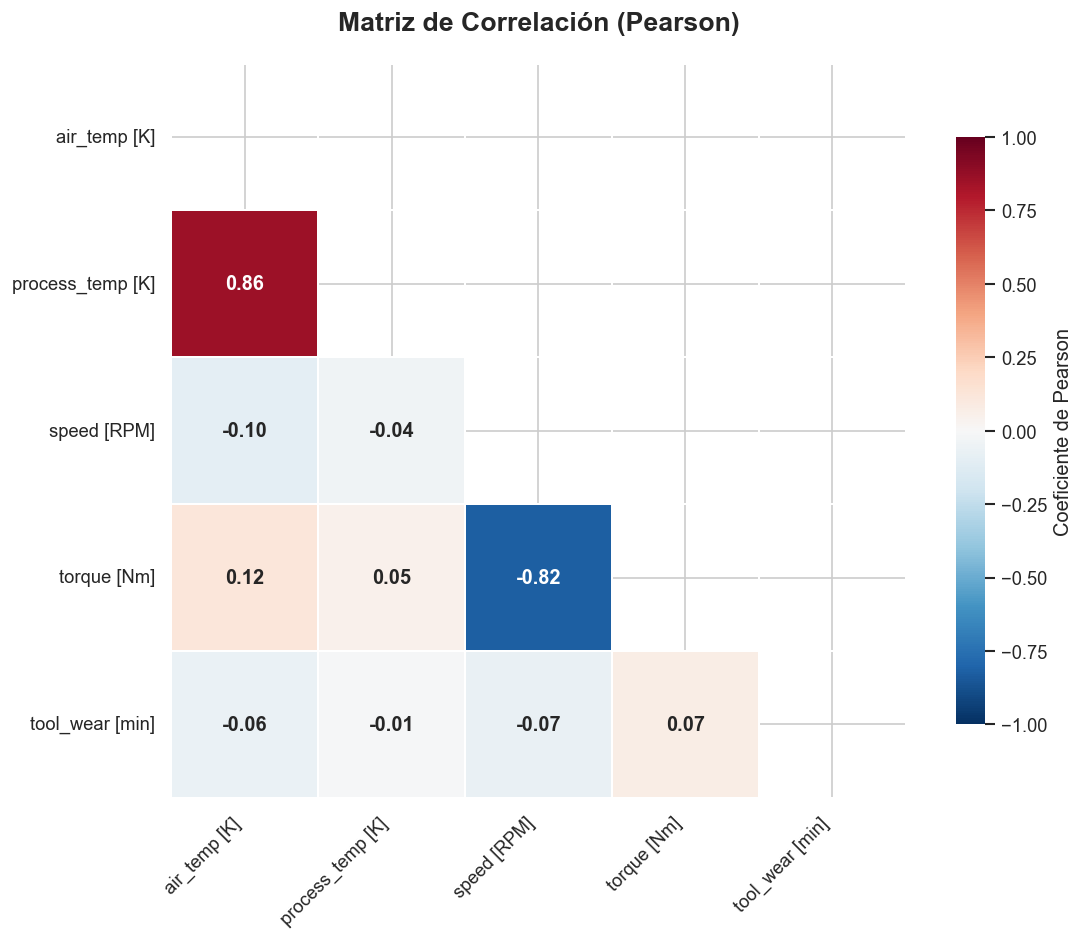

In [131]:
# --- Heatmap de la matriz de correlación (Pearson) ---

# Calcular la matriz de correlación solo para las columnas numéricas relevantes
corr_matrix = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Crear máscara para el triángulo superior (evitar redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Coeficiente de Pearson', 'shrink': 0.8})

ax.set_title('Matriz de Correlación (Pearson)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

#### Gráfico de Dispersión para Analizar Correlación entre Variables

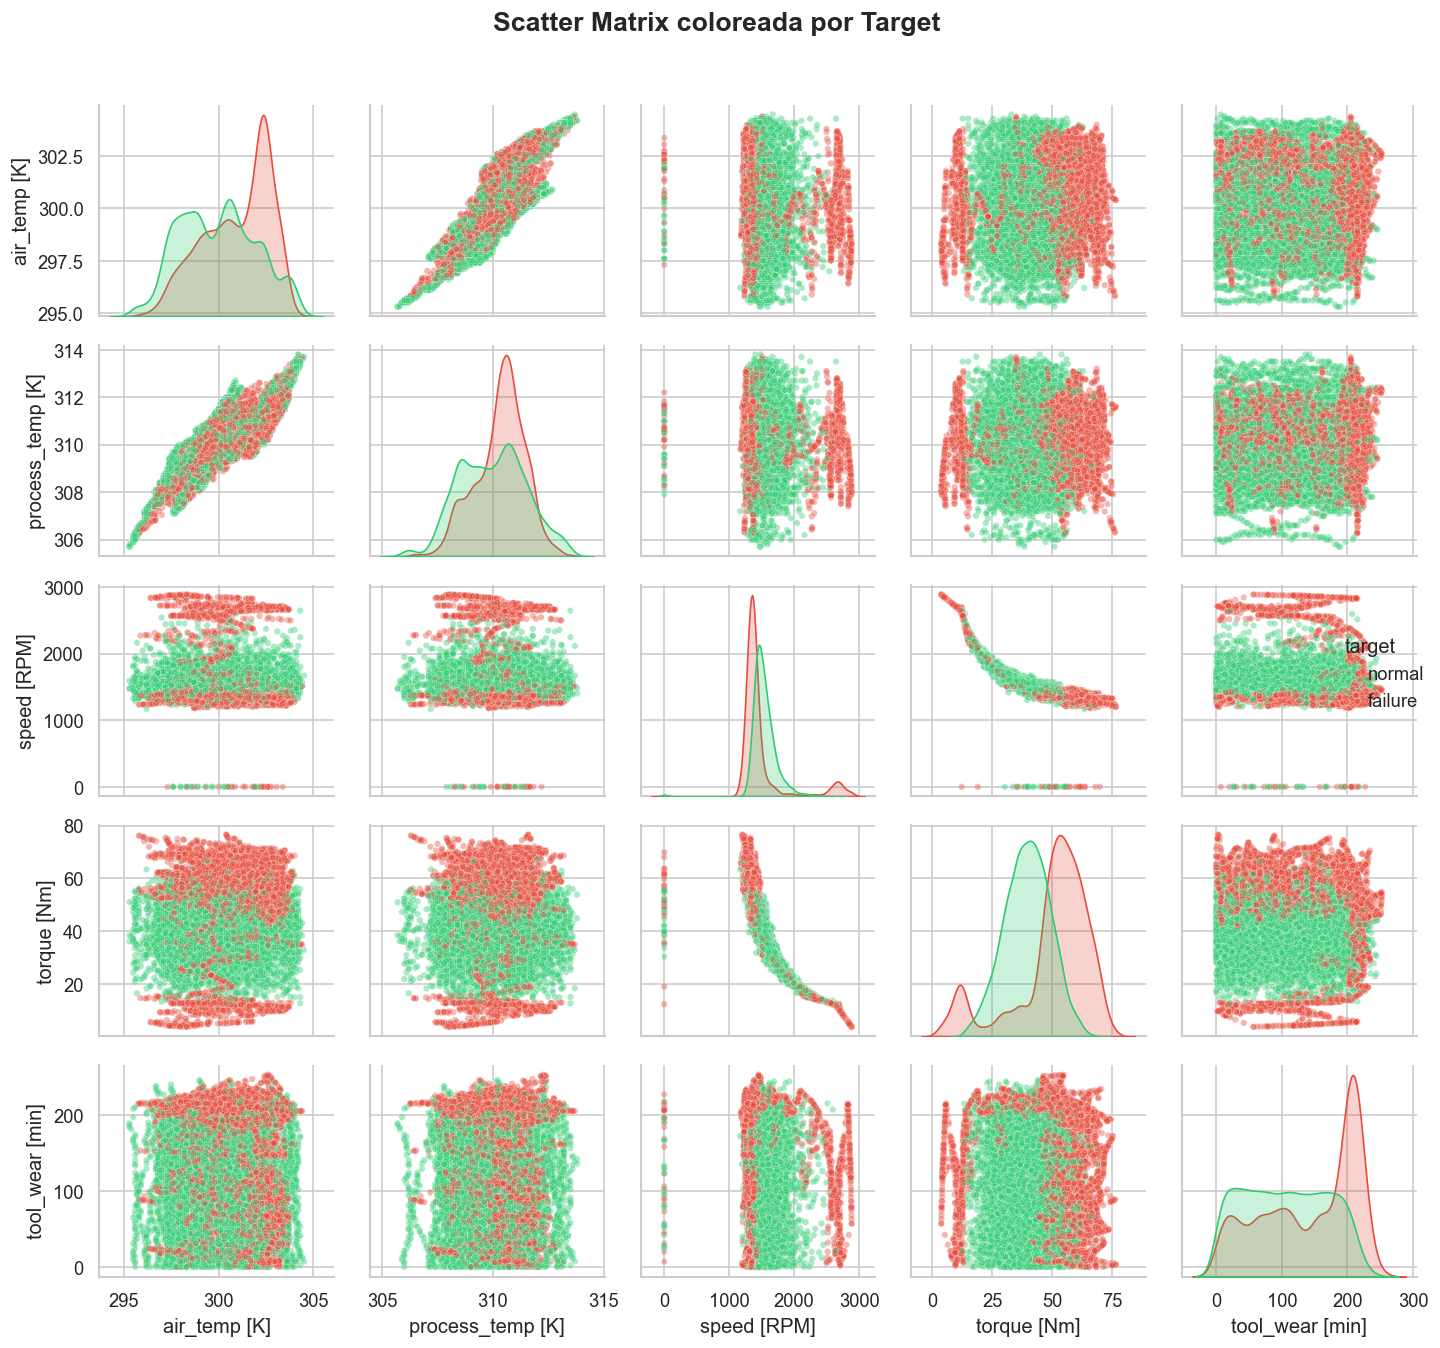

In [132]:
# --- Pairplot (scatter matrix) coloreado por la variable target ---

g = sns.pairplot(df[columnas_numericas + ['target']], hue='target',
                 palette={'failure': '#e74c3c', 'normal': '#2ecc71'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 height=2.2)

g.figure.suptitle('Scatter Matrix coloreada por Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- En este gráfico se puede observar que la relación entre speed [RPM] y torque [Nm] es bastante fuerte, lo que se refleja en el valor de la correlación de Pearson (-0.82) calculado anteriormente. Sin embargo, también se puede observar que dicha relación es no lineal, por lo que es importante también considerar la correlación de Spearman.
- Para el caso de air_temp [K] y process_temp [K], se puede observar que la relación entre ambas variables también es bastante fuerte, como sugiere el valor de la correlación de Pearson calculada anteriormente (0.86). En este caso, la relación sí pareciera ser lineal.

#### Correlación de Spearman

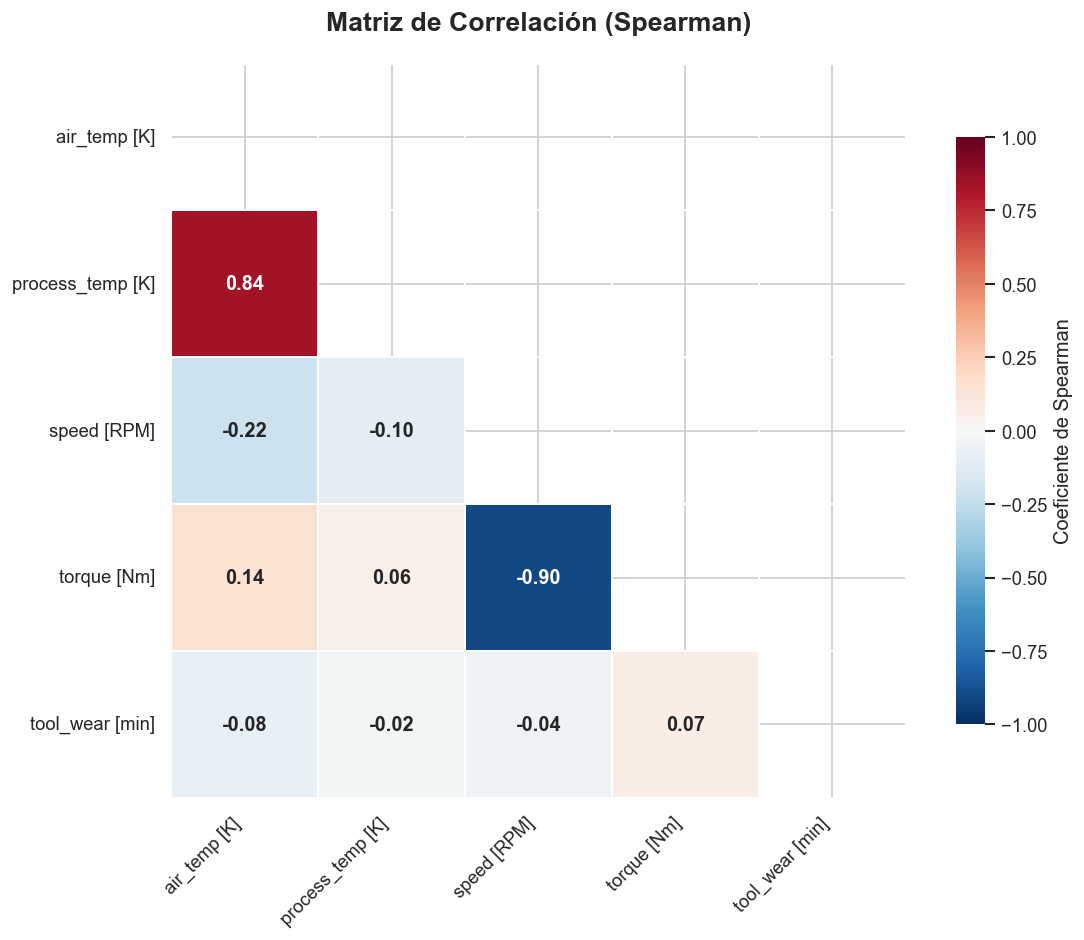

In [133]:
# --- Heatmap de la matriz de correlación (Spearman) ---
corr_spearman = df[columnas_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Coeficiente de Spearman', 'shrink': 0.8})

ax.set_title('Matriz de Correlación (Spearman)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

**Observaciones**:
- Con este resultado, podemos ver que la correlación de Spearman entre speed [RPM] y torque [Nm] es aún más fuerte que la correlación de Pearson, lo que sugiere que la relación entre estas dos variables es monotónica, aunque no necesariamente lineal. Esto refuerza la idea de que la relación entre speed y torque es fuerte, pero no lineal.

## Parte 2.1: Preprocesamiento de los Datos

### Eliminar Columnas Irrelevantes

In [134]:
# Eliminamos las columnas 'idx' y 'parent_device_id'
df = df.drop(columns=['idx', 'parent_device_id'])

### Codificación de Columnas Categóricas

In [135]:
# Aplicar One-Hot Encoding a la columna product_type
df = pd.get_dummies(df, columns=['product_type'], prefix='product_type', drop_first=False, dtype=int)

# Codificación de la variable objetivo (Target)
# Convertimos los valores string a numéricos (0 y 1) para que los modelos puedan procesarlos
df['target'] = df['target'].map({'normal': 0, 'failure': 1})

# Verificar el resultado
print("\nPrimeras filas del DataFrame con product_type codificado (One-Hot Encoding) y target codificado:")
df.head()


Primeras filas del DataFrame con product_type codificado (One-Hot Encoding) y target codificado:


,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target,product_type_H,product_type_L,product_type_M
0,303.80,313.30,1406,52.10,166,0,0,1,0
1,302.30,311.20,1633,36.40,114,0,0,1,0
2,302.27,311.47,1228,68.75,187,1,0,0,1
3,302.35,311.93,1522,36.99,214,1,0,1,0
4,296.70,307.90,1743,27.90,55,0,0,1,0


**Observación:** Si bien inicialmente interpretamos que la columna product_type era categórica ordinal (siendo L=Low, M=Medium y H=High), como el trabajo no provee información explícita decidimos no arriesgarnos a una interpretación errónea y optamos por aplicar One-Hot Encoding a esta columna, lo que nos permite preservar toda la información sin asumir un orden específico entre las categorías. De esta manera, cada categoría de product_type se representa como una columna binaria independiente, lo que facilita el análisis y modelado posterior sin introducir suposiciones sobre la relación entre las categorías.

### Verificación de Valores Faltantes

In [136]:
# Verificar si existen valores faltantes
df.isnull().sum()

air_temp [K]        40
process_temp [K]     0
speed [RPM]          0
torque [Nm]          0
tool_wear [min]      0
target               0
product_type_H       0
product_type_L       0
product_type_M       0
dtype: int64

**Observación**: Hay 40 filas con valores faltantes en la columna air_temp [K].

In [137]:
# Observamos las filas con la columna air_temp [K] faltante
df[pd.isnull(df['air_temp [K]'])]

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target,product_type_H,product_type_L,product_type_M
1448,NaN,312.40,1404,61.50,127,1,0,1,0
1449,NaN,311.51,1371,47.22,60,1,0,1,0
1450,NaN,309.51,1337,63.61,206,1,0,1,0
3901,NaN,309.82,1981,20.50,203,1,0,1,0
3902,NaN,311.00,1428,47.90,174,0,0,1,0
3903,NaN,312.34,2687,10.48,67,1,0,0,1
3904,NaN,311.50,1663,33.60,38,0,0,1,0
3905,NaN,308.00,1423,38.00,154,0,0,1,0
3906,NaN,311.10,1647,31.60,6,0,0,0,1
3907,NaN,308.80,1683,31.60,79,0,0,0,1


## División del dataset (80/20)

In [138]:
from sklearn.model_selection import train_test_split

# Separar features (X) y target (y)
X = df.drop(columns=['target'])
y = df['target']

# División 80% train / 20% test, con estratificación para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nDistribución de clases en train:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribución de clases en test:\n{y_test.value_counts(normalize=True)}")


Train: 11616 muestras (80.0%)
Test:  2905 muestras (20.0%)

Distribución de clases en train:
target
1    0.515238
0    0.484762
Name: proportion, dtype: float64

Distribución de clases en test:
target
1    0.515318
0    0.484682
Name: proportion, dtype: float64


## Imputación de Valores Inválidos
Para la imputación de valores inválidos (como los -1 de la columna speed), decidimos hacer lo siguiente:
Para cada fila con speed == -1:
- Buscar filas con torque parecido que tengan speed != -1
- Usar sus valores de speed para imputar el valor faltante.

In [139]:
# Visualizamos las filas con speed == -1
concatenado = pd.concat([X_train, X_test], axis=0)
indices_speed_negativo = concatenado[concatenado['speed [RPM]'] == -1].index
concatenado.loc[indices_speed_negativo].head()

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M
8668,298.90,309.60,-1,33.70,195,0,1,0
8677,303.06,311.50,-1,49.02,88,0,1,0
8687,300.30,310.40,-1,54.40,52,0,1,0
58,300.70,311.35,-1,19.05,227,0,0,1
51,300.70,310.60,-1,30.30,96,0,1,0


In [111]:
from sklearn.neighbors import KNeighborsRegressor

# 1. Entrenar el imputador usando únicamente los registros válidos de Train
train_validos = X_train[X_train['speed [RPM]'] != -1]

# Ajustamos un regresor de vecinos donde la entrada es el torque y la salida es la velocidad
imputador_speed = KNeighborsRegressor(n_neighbors=5)
imputador_speed.fit(train_validos[['torque [Nm]']], train_validos['speed [RPM]'])

# 2. Imputar en X_train (usando el modelo entrenado)
mask_invalidos_train = X_train['speed [RPM]'] == -1
if mask_invalidos_train.any():
    valores_imputados_train = imputador_speed.predict(X_train.loc[mask_invalidos_train, ['torque [Nm]']])
    X_train.loc[mask_invalidos_train, 'speed [RPM]'] = np.round(valores_imputados_train)
    print(f"Imputados {mask_invalidos_train.sum()} valores -1 en speed [train]")

# 3. Imputar en X_test (usando el modelo entrenado en Train, evitando fuga de datos)
mask_invalidos_test = X_test['speed [RPM]'] == -1
if mask_invalidos_test.any():
    valores_imputados_test = imputador_speed.predict(X_test.loc[mask_invalidos_test, ['torque [Nm]']])
    X_test.loc[mask_invalidos_test, 'speed [RPM]'] = np.round(valores_imputados_test)
    print(f"Imputados {mask_invalidos_test.sum()} valores -1 en speed [test]")


Imputados 40 valores -1 en speed [train]
Imputados 7 valores -1 en speed [test]


In [112]:
# Verificar que no queden filas con speed == -1 en X_train
print("Valores -1 en X_train['speed [RPM]']:", (X_train['speed [RPM]'] == -1).sum())
print("Valores -1 en X_test['speed [RPM]']:", (X_test['speed [RPM]'] == -1).sum())

Valores -1 en X_train['speed [RPM]']: 0
Valores -1 en X_test['speed [RPM]']: 0


In [113]:
# Verificar los valores imputados en las filas que antes tenían speed == -1
concatenado = pd.concat([X_train, X_test], axis=0)
concatenado.loc[indices_speed_negativo, 'speed [RPM]']

8668     1563
8677     1440
8687     1361
58       2060
51       1661
8680     1335
56       1336
1786     1352
55       1500
53       1374
8665     1424
8676     1423
8678     1373
12694    1528
8670     1340
8681     1332
1785     1328
1782     2608
49       1508
8673     1529
13395    1530
8675     1462
8674     1439
8671     1610
8682     1390
8667     1306
12696    1362
1783     1398
8666     1402
13396    1571
8664     1446
52       1563
13394    1391
57       1380
8672     1399
54       1343
13393    1331
8686     1339
8669     1528
8684     1341
12697    1349
12695    1287
1784     1354
8685     1366
8683     1357
8679     1507
50       1389
Name: speed [RPM], dtype: int64

## Normalización / Estandarización

Mirando las columnas:
- air_temp [K] → ~296-303 (rango pequeño)
- process_temp [K] → ~307-313 (rango pequeño)
- speed [RPM] → ~1200-1700 (rango grande)
- torque [Nm] → ~27-68 (rango medio)
- tool_wear [min] → ~0-250 (rango grande)

Las escalas son muy diferentes entre sí, por lo que se decidió escalar todas las columnas numericas, para que así los modelos basados en distancias (como KNN) trabajen bien.

In [143]:
from sklearn.preprocessing import StandardScaler

# Columnas numéricas a escalar
cols_to_scale = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
scaler = StandardScaler()

# fit_transform SOLO en train (para evitar data leakage)
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# transform en test (usando los parámetros aprendidos del train)
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print("Estadísticas del train después del escalado:")
print(X_train[cols_to_scale].describe().round(2))

Estadísticas del train después del escalado:
       air_temp [K]  process_temp [K]  speed [RPM]  torque [Nm]  \
count      11616.00          11616.00     11616.00     11616.00   
mean           0.00             -0.00        -0.00        -0.00   
std            1.00              1.00         1.00         1.00   
min           -2.67             -3.38        -4.84        -2.90   
25%           -0.82             -0.73        -0.51        -0.63   
50%            0.06              0.14        -0.28         0.13   
75%            0.89              0.69         0.15         0.70   
max            2.07              2.75         4.39         2.22   

       tool_wear [min]  
count         11616.00  
mean             -0.00  
std               1.00  
min              -1.79  
25%              -0.86  
50%               0.05  
75%               0.96  
max               1.82  


## Impotación de NaNs en air_temp

In [144]:
print (f"Cantidad de valores nulos en el conjunto de entrenamiento:\n{X_train.isnull().sum()}")
print (f"Cantidad de valores nulos en el conjunto de prueba:\n{X_test.isnull().sum()}")

Cantidad de valores nulos en el conjunto de entrenamiento:
air_temp [K]        0
process_temp [K]    0
speed [RPM]         0
torque [Nm]         0
tool_wear [min]     0
product_type_H      0
product_type_L      0
product_type_M      0
dtype: int64
Cantidad de valores nulos en el conjunto de prueba:
air_temp [K]        0
process_temp [K]    0
speed [RPM]         0
torque [Nm]         0
tool_wear [min]     0
product_type_H      0
product_type_L      0
product_type_M      0
dtype: int64


In [145]:
from sklearn.impute import KNNImputer

# Seleccionamos las variables numéricas que nos ayudarán a imputar razonablemente
columnas_imputacion = ['product_type_L', 'product_type_M', 'product_type_H', 'air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

# Inicializamos el imputador KNN con 5 vecinos 
imputer = KNNImputer(n_neighbors=5)

# Aplicamos la imputación de KNN y actualizamos las columnas en el dataset
X_train[columnas_imputacion] = imputer.fit_transform(X_train[columnas_imputacion]) #Aprender SOLO del train
X_test[columnas_imputacion] = imputer.transform(X_test[columnas_imputacion]) #Aplicar al test

**Observación**: Se imputa luego de haber normalizado/estandarizado ya que se utiliza un imputador basado en KNN. Como este es un modelo basado en distancias la escala importa, por lo que se debía realizar este tratamiento previo. No fue así para la imputación de Speed ya que se utilizó unicamente el Torque para realizar esta imputación, manteniendo los problemas de escalas distintas alejados. 

In [146]:
# Verificar que no queden valores faltantes
print (f"Cantidad de valores nulos en el conjunto de entrenamiento:\n{X_train.isnull().sum()}")
print (f"Cantidad de valores nulos en el conjunto de prueba:\n{X_test.isnull().sum()}")

Cantidad de valores nulos en el conjunto de entrenamiento:
air_temp [K]        0
process_temp [K]    0
speed [RPM]         0
torque [Nm]         0
tool_wear [min]     0
product_type_H      0
product_type_L      0
product_type_M      0
dtype: int64
Cantidad de valores nulos en el conjunto de prueba:
air_temp [K]        0
process_temp [K]    0
speed [RPM]         0
torque [Nm]         0
tool_wear [min]     0
product_type_H      0
product_type_L      0
product_type_M      0
dtype: int64


In [147]:
# Verificar los valores imputados en las filas que antes tenían air_temp [K] faltante
concatenado = pd.concat([X_train, X_test], axis=0)
concatenado.loc[indices_air_temp_nulo, 'air_temp [K]']

12118   -0.392809
12110   -0.619595
12104   -0.740203
14328    0.932855
12106   -0.052631
12114    1.310144
12121   -0.011397
3905    -0.073248
12100    1.123561
12108   -0.246429
12105    0.437020
1449     1.204998
12113    1.417351
12120   -0.140253
12111    0.974089
12101    0.614325
3904     0.906053
3906     0.225697
12103    0.751427
3907    -0.702062
12109   -0.135098
12117   -0.895860
14331    1.126654
14329    0.153538
12112    1.425598
12115   -0.877305
12102   -0.578361
3901    -0.521664
12116    0.399909
12107    1.243139
6682    -0.104173
14330    0.000973
12122   -0.011397
6683    -0.836072
6713     0.542166
1448     1.270972
1450    -0.604132
3902     0.297856
3903     1.534867
12119   -0.959773
Name: air_temp [K], dtype: float64

## Guardar dataset preprosesado

In [ ]:
import os

# --- Exportar ---
os.makedirs('data/processed', exist_ok=True)

train_df = X_train.copy()
train_df['target'] = y_train.values

test_df = X_test.copy()
test_df['target'] = y_test.values

train_df.to_csv('data/processed/train.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)

print(f"Train exportado: {train_df.shape[0]} filas, {train_df.shape[1]} columnas")
print(f"Test exportado: {test_df.shape[0]} filas, {test_df.shape[1]} columnas")

Train exportado: 11616 filas, 9 columnas
Test exportado: 2905 filas, 9 columnas


## Parte 2.2: Entrenamiento de Modelos

- Entrenar y mostrar los resultados obtenidos con los modelos KNN, Naive Bayes y Decision Trees
- Realizar búsqueda de hiperparámetros con RandomSearch
- Evaluar los modelos con las métricas convenientes.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Función reutilizable para evaluar modelos
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    print(f"--- Resultados para {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal (0)', 'Falla (1)'], 
                yticklabels=['Normal (0)', 'Falla (1)'])
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

### KNN

/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/pyth

Mejores hiperparámetros KNN: {'weights': 'uniform', 'n_neighbors': 1, 'metric': 'minkowski'}

--- Resultados para KNN ---
Accuracy:  0.9601
Precision: 0.9390
Recall:    0.9866
F1-Score:  0.9622

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      1408
           1       0.94      0.99      0.96      1497

    accuracy                           0.96      2905
   macro avg       0.96      0.96      0.96      2905
weighted avg       0.96      0.96      0.96      2905



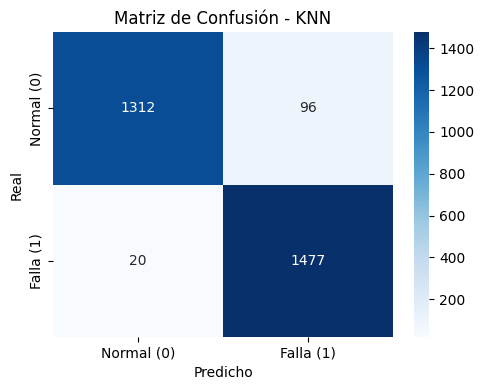

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Definir el espacio de búsqueda
param_dist_knn = {
    'n_neighbors': range(1, 40),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Inicializar modelo
knn = KNeighborsClassifier()

# Búsqueda de hiperparámetros con Random Search 
# (Optimizamos para f1 debido a la importancia de detectar fallas)
rs_knn = RandomizedSearchCV(knn, param_distributions=param_dist_knn, 
                            n_iter=50, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rs_knn.fit(X_train, y_train)

print(f"Mejores hiperparámetros KNN: {rs_knn.best_params_}\n")

# Evaluar el mejor modelo encontrado
best_knn = rs_knn.best_estimator_
evaluate_model(best_knn, X_test, y_test, "KNN")

### Naive Bayes

Mejores hiperparámetros Naive Bayes: {'var_smoothing': np.float64(0.3511191734215131)}

--- Resultados para Naive Bayes ---
Accuracy:  0.8437
Precision: 0.8337
Recall:    0.8704
F1-Score:  0.8516

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.82      0.83      1408
           1       0.83      0.87      0.85      1497

    accuracy                           0.84      2905
   macro avg       0.84      0.84      0.84      2905
weighted avg       0.84      0.84      0.84      2905



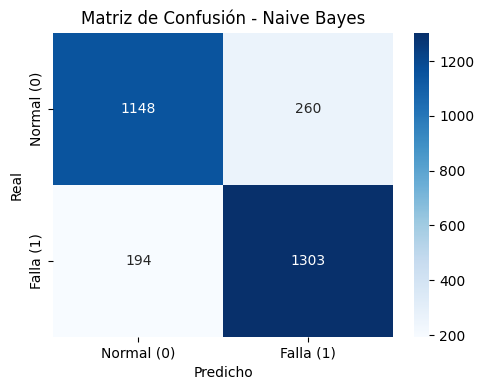

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Definir el espacio de búsqueda
#TODO: Ver como funciona var_smoothing y si conviene dejarlo o sacarlo
# var_smoothing ayuda a la estabilidad del cálculo al agregar una porción de la mayor varianza a todas las características
param_dist_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

nb = GaussianNB()

# Búsqueda de hiperparámetros con Random Search
rs_nb = RandomizedSearchCV(nb, param_distributions=param_dist_nb, 
                           n_iter=50, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rs_nb.fit(X_train, y_train)

print(f"Mejores hiperparámetros Naive Bayes: {rs_nb.best_params_}\n")

# Evaluar el mejor modelo encontrado
best_nb = rs_nb.best_estimator_
evaluate_model(best_nb, X_test, y_test, "Naive Bayes")

### Decision Trees

Total de combinaciones posibles: 8208


/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/pyth

Mejores hiperparámetros Decision Tree: {'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'entropy', 'class_weight': None}

--- Resultados para Decision Trees ---
Accuracy:  0.9528
Precision: 0.9462
Recall:    0.9633
F1-Score:  0.9547

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1408
           1       0.95      0.96      0.95      1497

    accuracy                           0.95      2905
   macro avg       0.95      0.95      0.95      2905
weighted avg       0.95      0.95      0.95      2905



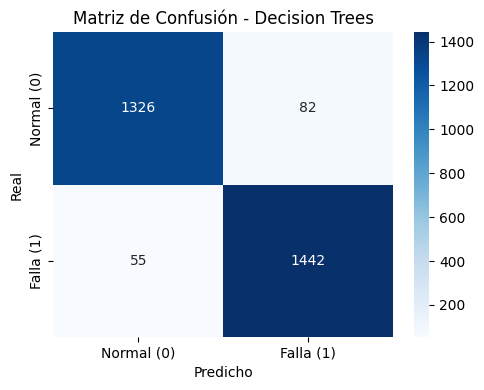

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterGrid

# Definir el espacio de búsqueda
param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 20),
    'class_weight': [None, 'balanced']  # ya que tenemos un ligero desbalanceo de clases
}
total_combinaciones = len(ParameterGrid(param_dist_dt))
print(f"Total de combinaciones posibles: {total_combinaciones}")

dt = DecisionTreeClassifier(random_state=42)

# Búsqueda de hiperparámetros con Random Search
rs_dt = RandomizedSearchCV(dt, param_distributions=param_dist_dt, 
                           n_iter=100, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rs_dt.fit(X_train, y_train)

print(f"Mejores hiperparámetros Decision Tree: {rs_dt.best_params_}\n")

# Evaluar el mejor modelo encontrado
best_dt = rs_dt.best_estimator_
evaluate_model(best_dt, X_test, y_test, "Decision Trees")

## Parte 2.3: Entrenamiento de Modelos Ensamblados

/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/pyth

Mejores hiperparámetros Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 30, 'criterion': 'entropy', 'class_weight': None, 'bootstrap': False}

--- Resultados para Random Forest ---
Accuracy:  0.9711
Precision: 0.9651
Recall:    0.9793
F1-Score:  0.9721

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1408
           1       0.97      0.98      0.97      1497

    accuracy                           0.97      2905
   macro avg       0.97      0.97      0.97      2905
weighted avg       0.97      0.97      0.97      2905



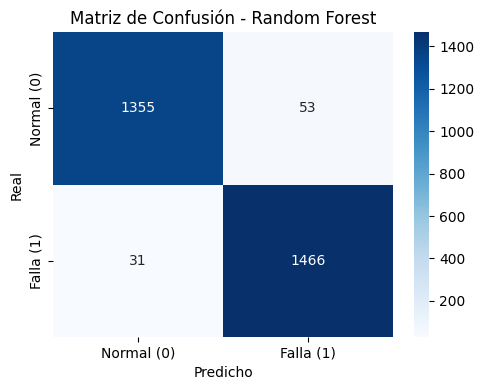

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Definir el espacio de búsqueda para Random Forest
param_dist_rf = {
    'n_estimators': [25, 50, 100, 200, 300, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 20),
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']  # ya que tenemos un ligero desbalanceo de clases
}
    
rf = RandomForestClassifier(random_state=42)

# Búsqueda de hiperparámetros con Random Search
rs_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf, 
                           n_iter=100, cv=5, scoring='f1', random_state=42, n_jobs=-1)
rs_rf.fit(X_train, y_train)

print(f"Mejores hiperparámetros Random Forest: {rs_rf.best_params_}\n")

# Evaluar el mejor modelo encontrado
best_rf = rs_rf.best_estimator_
evaluate_model(best_rf, X_test, y_test, "Random Forest")

## Parte 2.4: Comparación de Modelos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Diccionario de modelos ya entrenados (mejores estimadores de cada RandomizedSearch)
modelos = {
    'KNN': best_knn,
    'Naive Bayes': best_nb,
    'Decision Tree': best_dt,
    'Random Forest': best_rf
}

# Calcular métricas sobre el conjunto de prueba
filas = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    filas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

comparacion = pd.DataFrame(filas).set_index('Modelo').sort_values('F1-Score', ascending=False)
display(comparacion.round(4))

# --- Gráfico de barras comparativo ---
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparacion.index))
ancho = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, met in enumerate(metricas):
    ax.bar(x + i * ancho, comparacion[met], ancho, label=met, color=colores[i], edgecolor='white')

ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(comparacion.index, fontsize=11)
ax.set_ylabel('Valor de la métrica', fontsize=12)
ax.set_ylim(0.80, 1.0)  # zoom para apreciar las diferencias
ax.set_title('Comparación de Modelos por Métrica', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()